# χ行列の主要エラー要素とdrive校正

このノートは**設定と実行だけ**を担当します。関数、QPT、CPTP射影、fit、描画、キャッシュ処理はPython側へ移しました。

- 設定API: `chi_error_nbar_workflow.py`
- 解析実装: `chi_error_nbar_analysis_impl.py`
- 独立検証ステージ: `chi_error_nbar_stages.py`
- drive補正式: `drive_amplitude_calibration.py`
- drive再QPT解析: `drive_calibration_qpt_analysis.py`

通常は下の設定セルだけ変更し、最後の`workflow.run(CONFIG)`を実行してください。重いフラグは既定で`False`です。

In [2]:
import importlib

import numpy as np
import pandas as pd
from IPython.display import display

import chi_error_nbar_workflow as workflow
import chi_error_nbar_stages as stages
workflow = importlib.reload(workflow)
stages = importlib.reload(stages)

## 1. 共通設定

通常変更するのはこのセルです。

In [3]:
CONFIG = workflow.default_config()

CONFIG["OUTPUT_DIR"] = "results/chi_error_element_fit"
CONFIG["NBAR_GRID"] = np.r_[0.01, np.arange(0.25, 20.0001, 0.25)]
CONFIG["FIT_DEGREE"] = 4
CONFIG["ERROR_CHANNEL_CONVENTION"] = "undo_before_actual"

# 並列数。高n_barではメモリ使用量も増えるため、まず4を推奨。
CONFIG["PARALLEL_WORKERS"] = 24
CONFIG["FAST_PROCESS_WORKERS"] = 24

display(pd.Series({
    key: value for key, value in CONFIG.items()
    if key not in {"SIMULATION_PARAMS", "NBAR_GRID"}
}, name="value").to_frame())

,value
OUTPUT_DIR,results/chi_error_element_fit
RECOMPUTE,False
PARALLEL_WORKERS,24
FAST_PROCESS_WORKERS,24
FIT_DEGREE,4
ERROR_CHANNEL_CONVENTION,undo_before_actual
RUN_EXACT_FULL_CHI_SWEEP,False
RUN_NUMERICAL_CONVERGENCE,False
RUN_NOISE_SOURCE_ABLATION,False
FORCE_RECOMPUTE_PUBLICATION_CACHE,False


## 2. Hamiltonian・ノイズ設定

物理条件を変更する場合はこのセルだけ編集します。

In [4]:
SIMULATION_PARAMS = CONFIG["SIMULATION_PARAMS"]
SIMULATION_PARAMS.update({
    "A": 0.125,
    "delta": 0.5,
    "rho0": 0.0,
    "time_points": 500,
    "t_gate_phys": 100e-6,
    "heating_rate_phys": 10.0,
    "dephasing_rate_phys": 18.0,
    "T2_star": 0.3,
    "rayleigh_rate_phys": 3.0,
    "raman_rate_phys": 1.0,
    "eta": 0.1,
    "laser_intensity_fluctuation": 0.0,
    "laser_detuning_fluctuation": 0.0,
    "laser_rotation_angle_fluctuation": 0.0,
    "laser_noise_samples": 1,
    "laser_noise_seed": 1234,
    "use_full_order": True,
    "show_progress": True,
    "parallel_workers": CONFIG["PARALLEL_WORKERS"],
})
display(pd.Series(SIMULATION_PARAMS, name="value").to_frame())

,value
A,0.125
delta,0.5
rho0,0.0
time_points,500
t_gate_phys,0.0001
heating_rate_phys,10.0
dephasing_rate_phys,18.0
T2_star,0.3
rayleigh_rate_phys,3.0
raman_rate_phys,1.0


## 3. 論文用検証フラグ

`False`では保存済みキャッシュを読みます。`True`は不足点を計算します。`FORCE_*`は既存キャッシュも再計算します。

In [5]:
CONFIG.update({
    "RECOMPUTE": False,
    "RUN_EXACT_FULL_CHI_SWEEP": False,
    "RUN_NUMERICAL_CONVERGENCE": False,
    "RUN_NOISE_SOURCE_ABLATION": False,
    "FORCE_RECOMPUTE_PUBLICATION_CACHE": False,
    "CONVERGENCE_NBARS": [0.01, 4.0, 20.0],
    "ABLATION_NBARS": [0.01, 1.0, 4.0, 10.0, 20.0],
    "BOOTSTRAP_SAMPLES": 1000,
    "BOOTSTRAP_SEED": 20260805,
    "CPTP_TOLERANCE": 1e-11,
    "CPTP_MAX_ITERATIONS": 5000,
    "FORCE_RECOMPUTE_ADVANCED_QPT": False,
    "RUN_PHYSICAL_CONTROL_QPT": False,
    "RUN_PARAMETER_ROBUSTNESS_QPT": False,
    "CONTROL_VALIDATION_NBARS": [0.01, 1.0, 2.0, 3.0, 4.0],
    "ROBUSTNESS_NBARS": [0.01, 1.0, 2.0, 3.0, 4.0],
})

## 4. $h_{XX}$ drive-amplitude校正

`RUN_HXX_DRIVE_CALIBRATION_QPT=True`にすると、補正振幅でfull-order master-equation QPTを実行します。各温度点は独立キャッシュなので中断・再開できます。

In [6]:
CONFIG.update({
    "RUN_HXX_DRIVE_CALIBRATION_QPT": False,
    "FORCE_RECOMPUTE_HXX_DRIVE_QPT": False,
    "HXX_DRIVE_CALIBRATION_NBARS": [
        0.01, 1.0, 2.0, 4.0, 6.0, 8.0, 10.0, 12.0, 16.0, 20.0,
    ],
    "HXX_MAX_FEEDBACK_ITERATIONS": 2,
    "HXX_CONVERGENCE_TOL_RAD": 2e-3,
    "HXX_MAX_AMPLITUDE_FACTOR": 1.6,
    "TARGET_XX_ANGLE_RAD": np.pi / 4.0,

    # 実機値がある場合: K = f_mode[Hz] * t_gate[s]
    "KIRCHHOFF_REFERENCE_K": None,
    "KIRCHHOFF_LOOP_NUMBER": 1.0,
    "KIRCHHOFF_SCAN_K_MAX": 250.0,
})

## 5. 基本解析と保存済み検証の読込

設定を検証した後、解析本体を一度だけ呼びます。重いフラグが`False`なら既存キャッシュを読みます。以下の独立検証セルより先に一度実行してください。

In [60]:
workflow.validate_config(CONFIG)
RESULTS = workflow.run(CONFIG)
print("analysis completed")

Sweep points: 81 (0.01 ... 20.0)
Cache: results/chi_error_element_fit/chi_error_element_sweep.csv
RECOMPUTE = False
data_source
direct_simulation    81


,n_bar,chi_XX_XX,chi_II_XX_real,chi_II_XX_imag,chi_II_XX_abs,data_source
0,0.01,0.000353,-0.000524,0.013702,0.013712,direct_simulation
1,0.25,0.000537,-0.000652,0.017362,0.017375,direct_simulation
2,0.50,0.000784,-0.000783,0.021154,0.021168,direct_simulation
3,0.75,0.001086,-0.000912,0.024922,0.024938,direct_simulation
4,1.00,0.001443,-0.001040,0.028665,0.028684,direct_simulation


,n_bar,chi_XX_XX,chi_II_XX_real,chi_II_XX_imag,chi_II_XX_abs,data_source
76,19.00,0.101549,-0.006603,0.218649,0.218748,direct_simulation
77,19.25,0.103312,-0.006645,0.220304,0.220404,direct_simulation
78,19.50,0.105075,-0.006686,0.221939,0.222039,direct_simulation
79,19.75,0.106836,-0.006727,0.223554,0.223655,direct_simulation
80,20.00,0.108596,-0.006767,0.225149,0.225251,direct_simulation


,element,degree,R_squared,RMSE,max_abs_residual
0,"\chi_{XX,XX}",1,0.946932,0.007761,0.012785
1,"\chi_{XX,XX}",2,0.997520,0.001678,0.003694
2,"\chi_{XX,XX}",3,0.999973,0.000174,0.000442
3,"\chi_{XX,XX}",4,1.000000,0.000007,0.000022
4,"\chi_{XX,XX}",5,1.000000,0.000003,0.000009
5,"|\chi_{II,XX}|",1,0.968919,0.010920,0.022739
6,"|\chi_{II,XX}|",2,0.999973,0.000322,0.000999
7,"|\chi_{II,XX}|",3,0.999995,0.000139,0.000280
8,"|\chi_{II,XX}|",4,1.000000,0.000033,0.000080
9,"|\chi_{II,XX}|",5,1.000000,0.000004,0.000011


,element,degree,n_bar_anchor,value_at_anchor,R_squared,RMSE,max_abs_residual,equation,a1,a2,a3,a4
0,"\chi_{XX,XX}",4,0.01,0.000353,1.0,0.000007,0.000022,y(n) = 3.52629218e-04 + 6.58124182e-04(n-0.01)...,0.000658,0.000465,-0.000015,1.788963e-07
1,"|\chi_{II,XX}|",4,0.01,0.013712,1.0,0.000033,0.000080,y(n) = 1.37116490e-02 + 1.54009743e-02(n-0.01)...,0.015401,-0.000220,-0.000004,1.387494e-07


...

,target,model,model_family,parameter_count,RMSE,AICc,BIC,CV_RMSE_5fold,equation,best_AICc_overall,best_AICc_physical
2,chi_XX_XX,thermal_bosonic_3,thermal_physics,4,0.000142,-1426.685843,-1417.634362,0.000819,y(n) = (-3.74423723e-04)*1 + (3.35722386e-04)*...,False,True
6,abs_chi_II_XX,thermal_bosonic_3,thermal_physics,4,0.000104,-1477.062412,-1468.010932,0.000558,y(n) = (5.18886154e-03)*1 + (8.01669430e-03)*(...,False,True
10,chi_IX_IX,thermal_bosonic_3,thermal_physics,4,0.000003,-2060.070392,-2051.018911,0.000015,y(n) = (2.82111360e-04)*1 + (2.70835026e-04)*(...,False,True
14,chi_XI_XI,thermal_bosonic_3,thermal_physics,4,0.000003,-2060.093996,-2051.042516,0.000015,y(n) = (2.82120317e-04)*1 + (2.70832299e-04)*(...,False,True
18,generator_h_XX,thermal_bosonic_3,thermal_physics,4,0.000022,-1729.634338,-1720.582857,0.000103,y(n) = (5.67424617e-03)*1 + (7.82387919e-03)*(...,False,True
22,generator_gamma_XX,thermal_bosonic_3,thermal_physics,4,0.000063,-1559.248614,-1550.197133,0.000357,y(n) = (-1.40738770e-04)*1 + (1.22048651e-04)*...,False,True


/Users/hirainoa/Desktop/量子/project/Moon_shot__高橋PJ/MS_gate_Hirai/chi_error_nbar_analysis_impl.py:2972: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  "result": (


,check,status,result
0,CPTP projection,complete,"CP=81/81, TP=81/81"
1,CPTP conclusion stability,complete,"Top-12 overlap=12/12, max ||delta chi||_F=4.02..."
2,XX error-generator separation,complete,h_XX: 1.3736e-02 -> 2.6508e-01 rad/gate; gamma...
3,Channel-level XX compensation,complete,n_bar=20: avg infidelity 9.8530e-02 -> 4.9633e...
4,hXX-derived drive calibration re-QPT,complete,10/10 temperatures re-QPT; 10 with |h_XX| <= 2...
5,Physical-control re-QPT,pending,45/55 non-baseline QPT points
6,Parameter robustness re-QPT,pending,0/45 non-baseline QPT points
7,Thermal physical-model comparison,complete,best physical model saved for 6 targets; gener...


**現時点の結論:** CPTP安定性・generator分解・channel-level補正は完了しました。実Hamiltonianでの制御再QPTとパラメータ頑健性QPTは未完了です。

analysis completed


## 6. 独立実行：drive補正後のfull-Hamiltonian再QPT

10温度点を集計します。`RUN_DRIVE_RE_QPT=True`で不足点だけを計算し、完了済み点はキャッシュから自動的に読みます。実行後は論文用チェックリストも即座に更新されます。

In [ ]:
DRIVE_RE_QPT_NBARS = list(CONFIG["HXX_DRIVE_CALIBRATION_NBARS"])
RUN_DRIVE_RE_QPT = False
FORCE_DRIVE_RE_QPT = False

DRIVE_RE_QPT_RESULT = stages.run_drive_feedback_stage(
    CONFIG,
    DRIVE_RE_QPT_NBARS,
    run_qpt=RUN_DRIVE_RE_QPT,
    force_recompute=FORCE_DRIVE_RE_QPT,
    max_feedback_iterations=CONFIG["HXX_MAX_FEEDBACK_ITERATIONS"],
)
print(DRIVE_RE_QPT_RESULT["status"])
if not DRIVE_RE_QPT_RESULT["summary"].empty:
    display(DRIVE_RE_QPT_RESULT["summary"])

## 7. フォノン数ごとのXX角

熱平均の $\bar n$ ではなく、各Fock状態 $|n\rangle$ から出発したときのXX角
$\theta_{XX}^{(n)}=\tfrac12\arg\langle n|U_{S_x=+2}(T)|n\rangle$ を出します。
$h_{XX}^{(n)}=\pi/4-\theta_{XX}^{(n)}$ です。この計算はLindbladノイズを外し、full-order Hamiltonianが生む熱的な角ずれと残留spin-motion entanglementを切り分けます。

既定は代表的な低温・中間・高温の3校正振幅とbaselineの計4曲線です。`FOCK_ANGLE_REFERENCE_NBARS`を変えれば比較点を追加できます。

In [ ]:
import importlib
from IPython.display import Image

stages = importlib.reload(stages)

FOCK_ANGLE_REFERENCE_NBARS = [0.01, 4.0, 20.0]
FOCK_THERMAL_TAIL_TOLERANCE = 1e-5
FOCK_MAX_N = None  # None: 最大bar-nとtail toleranceから自動決定
FOCK_PLOT_MAX_N = 80
FOCK_PHONON_BUFFER = 24
FORCE_FOCK_ANGLE_RECOMPUTE = False
SHOW_FOCK_ANGLE_PROGRESS = True

FOCK_XX_RESULT = stages.run_fock_xx_angle_stage(
    CONFIG,
    FOCK_ANGLE_REFERENCE_NBARS,
    thermal_tail_tolerance=FOCK_THERMAL_TAIL_TOLERANCE,
    max_fock_n=FOCK_MAX_N,
    plot_max_fock_n=FOCK_PLOT_MAX_N,
    phonon_buffer=FOCK_PHONON_BUFFER,
    force_recompute=FORCE_FOCK_ANGLE_RECOMPUTE,
    show_progress=SHOW_FOCK_ANGLE_PROGRESS,
)
print(FOCK_XX_RESULT["status"])
display(FOCK_XX_RESULT["matched_summary"][[
    "condition", "thermal_n_bar", "amplitude",
    "effective_theta_xx_rad", "predicted_h_XX_rad_per_gate",
    "gamma_XX_phase_dispersion_per_gate",
    "gamma_XX_with_residual_motion_per_gate",
    "qpt_h_XX_rad_per_gate", "qpt_gamma_XX_per_gate",
    "thermal_tail_mass",
]])
display(Image(filename=str(FOCK_XX_RESULT["figure_path"])))

## 8. 独立実行：Kirchhoff解析式との直接比較

`K=f_mode[Hz] * t_gate[s]`です。実機のmode周波数を設定するか、既知の`K`を設定してください。両方が`None`の場合は計算せず待機します。

In [ ]:
KIRCHHOFF_MODE_FREQUENCY_HZ = None
KIRCHHOFF_REFERENCE_K = None
KIRCHHOFF_LOOP_NUMBER = 1.0

KIRCHHOFF_DIRECT_RESULT = None
if KIRCHHOFF_MODE_FREQUENCY_HZ is None and KIRCHHOFF_REFERENCE_K is None:
    print("Set KIRCHHOFF_MODE_FREQUENCY_HZ or KIRCHHOFF_REFERENCE_K.")
else:
    KIRCHHOFF_DIRECT_RESULT = stages.run_kirchhoff_direct_comparison_stage(
        CONFIG,
        mode_frequency_hz=KIRCHHOFF_MODE_FREQUENCY_HZ,
        reference_k=KIRCHHOFF_REFERENCE_K,
        loop_number=KIRCHHOFF_LOOP_NUMBER,
    )
    print(KIRCHHOFF_DIRECT_RESULT["reference"])
    display(KIRCHHOFF_DIRECT_RESULT["comparison"])

: 

### 8.1 Kirchhoff論文のinfidelityを元Hamiltonianから再現

Kirchhoff--Wilhelm--Motzoi, PRX Quantum **6**, 010328 (2025) のEq. (14), (17)--(19)を独立に実装し、論文と同じ`K=28`, `L=25`, $\eta=0.18$, $N_{\rm dim}=8$, $|m|\leq3$で時間発展します。評価量はAppendix B Eq. (B6)の**average gate-overlap fidelity**であり、このノートのQPTから得る標準的なaverage gate fidelityとは別の定義です。

`adaptive_dop853`は論文と同じHamiltonianを高精度ODEで高速に解きます。Eq. (43)の左端Trotter積をそのまま使う場合は`paper_trotter`に変更できますが、大幅に重くなります。propagatorは$\Omega$ごとにcacheされ、$\bar n$の追加は再時間発展不要です。

{'completed_drive_points': 14, 'expected_drive_points': 14, 'newly_computed': 0, 'pending_drive_points': 0, 'run_simulation': False, 'solver': 'adaptive_dop853', 'parallel_workers': 4, 'K': 28.0, 'L': 25.0, 'eta': 0.18, 'phonon_dim': 8, 'sideband_cutoff': 3, 'gate_duration_seconds': 2.8e-05, 'paper_fidelity_definition': 'Appendix B Eq. (B6) gate-overlap amplitude'}
Analytic drive landmarks [MHz]: {'omega_ld': 1.0503254405298408, 'omega_2': 1.0688994744694775, 'omega_4': 1.0891924703937843}


,landmark,omega_per_second,omega_mhz,simulated_average_infidelity,paper_reported_average_infidelity,relative_average_difference,simulated_bell_infidelity,paper_reported_bell_infidelity,relative_bell_difference
0,Omega_2,1.068899e+06,1.068899,0.000707,0.00067,0.055563,0.001376,0.00130,0.058690
1,Omega_4,1.089192e+06,1.089192,0.000281,0.00024,0.171135,0.000488,0.00043,0.135053


,omega_mhz,landmark,paper_average_infidelity,paper_bell_infidelity,thermal_tail_mass
6,1.040000,sweep,0.002593,0.005195,2.184935e-14
20,1.050000,sweep,0.001776,0.003546,2.184935e-14
34,1.050325,Omega_LD,0.001752,0.003498,2.184935e-14
48,1.060000,sweep,0.001132,0.002241,2.184935e-14
62,1.068899,Omega_2,0.000707,0.001376,2.184935e-14
76,1.070000,sweep,0.000665,0.001289,2.184935e-14
90,1.080000,sweep,0.000379,0.000701,2.184935e-14
104,1.089192,Omega_4,0.000281,0.000488,2.184935e-14
118,1.090000,sweep,0.000280,0.000485,2.184935e-14
132,1.100000,sweep,0.000371,0.000650,2.184935e-14


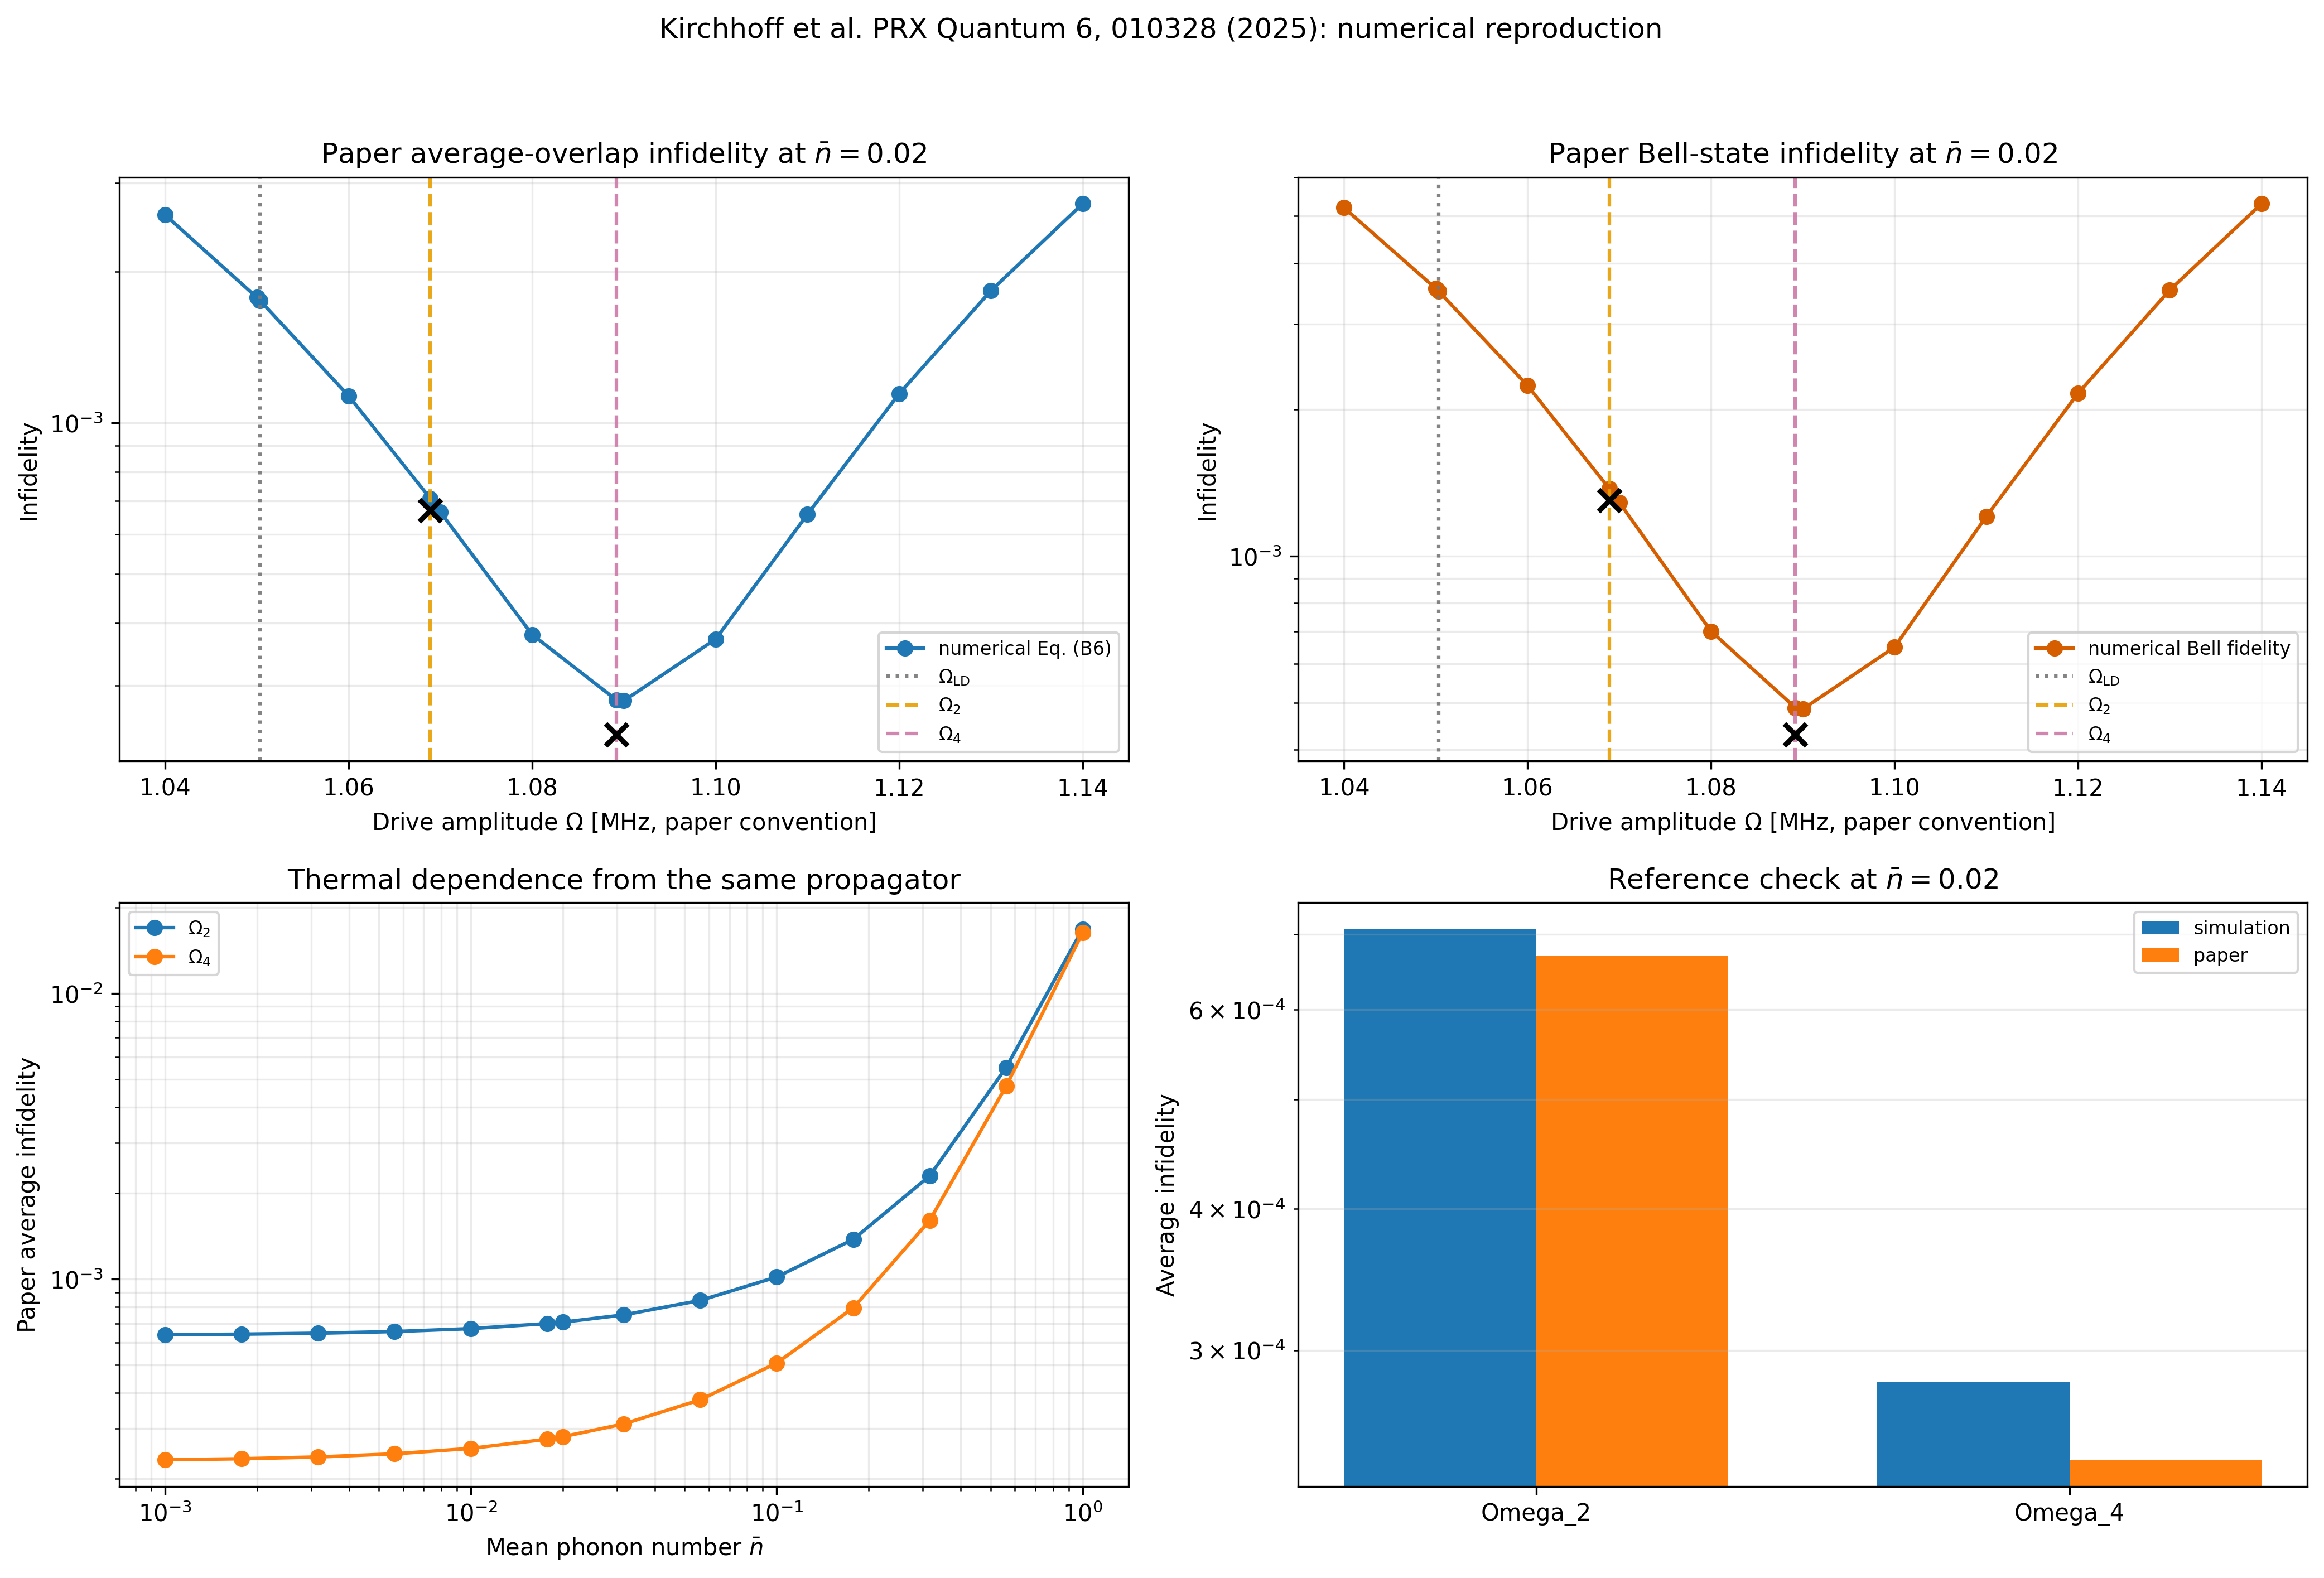

In [47]:
import importlib
from IPython.display import Image

stages = importlib.reload(stages)

# Fig. 2, Fig. 3, Fig. 5の基準パラメータ
KIRCHHOFF_PAPER_K = 28.0
KIRCHHOFF_PAPER_K_MINUS_L = 3.0
KIRCHHOFF_PAPER_MODE_FREQUENCY_HZ = 1.0e6
KIRCHHOFF_PAPER_ETA = 0.18
KIRCHHOFF_PAPER_PHONON_DIM = 8
KIRCHHOFF_PAPER_SIDEBAND_CUTOFF = 3

# Omega sweepは重い。n_bar sweepは同じpropagatorの熱重みを変えるだけで軽い。
KIRCHHOFF_PAPER_OMEGA_MHZ = np.linspace(1.04, 1.14, 11).tolist()
KIRCHHOFF_PAPER_NBARS = sorted(set(
    [0.02] + np.geomspace(1.0e-3, 1.0, 13).tolist()
))

KIRCHHOFF_PAPER_SOLVER = "adaptive_dop853"  # 速い高精度解
# KIRCHHOFF_PAPER_SOLVER = "paper_trotter"  # 論文Eq. (43)の積、非常に重い
KIRCHHOFF_PAPER_TROTTER_STEPS = None
KIRCHHOFF_PAPER_TROTTER_STEP_SCALE = 1.0
KIRCHHOFF_PAPER_WORKERS = min(4, int(CONFIG.get("FAST_PROCESS_WORKERS", 4)))

# Falseでは既存cacheだけ読み込む。全Omega sweepの時間発展を行う時だけTrue。
RUN_KIRCHHOFF_PAPER_SIMULATION = False
FORCE_KIRCHHOFF_PAPER_RECOMPUTE = False
SHOW_KIRCHHOFF_PAPER_PROGRESS = True

KIRCHHOFF_PAPER_RESULT = stages.run_kirchhoff_paper_infidelity_stage(
    CONFIG,
    K=KIRCHHOFF_PAPER_K,
    k_minus_l=KIRCHHOFF_PAPER_K_MINUS_L,
    mode_frequency_hz=KIRCHHOFF_PAPER_MODE_FREQUENCY_HZ,
    eta=KIRCHHOFF_PAPER_ETA,
    nbar_values=KIRCHHOFF_PAPER_NBARS,
    omega_mhz_values=KIRCHHOFF_PAPER_OMEGA_MHZ,
    phonon_dim=KIRCHHOFF_PAPER_PHONON_DIM,
    sideband_cutoff=KIRCHHOFF_PAPER_SIDEBAND_CUTOFF,
    solver=KIRCHHOFF_PAPER_SOLVER,
    trotter_steps=KIRCHHOFF_PAPER_TROTTER_STEPS,
    trotter_step_scale=KIRCHHOFF_PAPER_TROTTER_STEP_SCALE,
    parallel_workers=KIRCHHOFF_PAPER_WORKERS,
    run_simulation=RUN_KIRCHHOFF_PAPER_SIMULATION,
    force_recompute=FORCE_KIRCHHOFF_PAPER_RECOMPUTE,
    show_progress=SHOW_KIRCHHOFF_PAPER_PROGRESS,
)

print(KIRCHHOFF_PAPER_RESULT["status"])
print("Analytic drive landmarks [MHz]:", KIRCHHOFF_PAPER_RESULT["landmarks"])
display(KIRCHHOFF_PAPER_RESULT["reference_comparison"])

KIRCHHOFF_PAPER_SUMMARY = KIRCHHOFF_PAPER_RESULT["summary"]
if not KIRCHHOFF_PAPER_SUMMARY.empty:
    display(KIRCHHOFF_PAPER_SUMMARY.loc[
        np.isclose(KIRCHHOFF_PAPER_SUMMARY["n_bar"], 0.02),
        ["omega_mhz", "landmark", "paper_average_infidelity",
         "paper_bell_infidelity", "thermal_tail_mass"],
    ].sort_values("omega_mhz"))

if KIRCHHOFF_PAPER_RESULT["figure_path"] is not None:
    display(Image(filename=str(KIRCHHOFF_PAPER_RESULT["figure_path"])))
if KIRCHHOFF_PAPER_RESULT["status"]["pending_drive_points"]:
    print("Set RUN_KIRCHHOFF_PAPER_SIMULATION=True to compute pending Omega points.")

### 8.2 Kirchhoff propagatorを熱平均qubit channelへ変換してQPT解析

Cell 8.1でcacheした全系propagator $U(T)$から、熱状態 $p_n$に対するKraus演算子

$$K_{mn}=\sqrt{p_n}\langle m|U(T)|n\rangle,\qquad \mathcal E_{\rm q}(\rho)=\sum_{m,n}K_{mn}\rho K_{mn}^\dagger$$

を構成してmotionをtrace outします。Kirchhoff論文の$YY$ゲートは、$C=R_z(-\pi/2)\otimes R_z(-\pi/2)$による$C(YY)C^\dagger=XX$の局所基底変換を施します。その後、このノートと同じ理想$XX$ゲート除去規約、CPTP射影、QPT、$\log R$ error-generator分解へ通します。

出力する`average_infidelity`は標準的なchannel average infidelityです。Cell 8.1の`paper_average_infidelity`（Appendix B Eq. (B6)）とは定義が違うため、同じ表とグラフで両方を比較します。このセルは時間発展を再実行せず、既存propagatorの部分traceと16次元PTM解析だけを行います。

8.2 Kirchhoff thermal QPT:   0%|          | 0/196 [00:00<?, ?channel/s]

{'completed_channel_points': 196, 'expected_channel_points': 196, 'newly_computed': 0, 'pending_channel_points': 0, 'missing_propagator_caches': 0, 'error_channel_convention': 'undo_before_actual', 'yy_to_xx_basis_mapping': 'Rz(-pi/2) tensor Rz(-pi/2)', 'qpt_pipeline': 'CPTP projection -> PTM -> log(PTM) -> Pauli generator', 'raw_cp_pass': 196, 'raw_tp_pass': 196, 'max_kraus_completeness_error': 8.87717451456642e-15, 'max_cptp_projection_shift': 2.4021540602824846e-15}
Landmarks at n_bar=0.02


,landmark,omega_mhz,average_infidelity,paper_average_infidelity,h_XX_rad_per_gate,gamma_XX_per_gate,raw_cp_pass,raw_tp_pass,chi_cptp_projection_frobenius_shift
86,Omega_LD,1.050325,0.002775,0.001752,0.055216,0.000038,True,True,9.477406e-16
88,Omega_2,1.068899,0.001103,0.000707,0.030201,0.000041,True,True,6.361319e-16
91,Omega_4,1.089192,0.000420,0.000281,0.002451,0.000043,True,True,1.284790e-15


Best cached drive point for each n_bar (standard channel metric)


,n_bar,omega_mhz,landmark,average_infidelity,h_XX_rad_per_gate,gamma_XX_per_gate
8,0.001000,1.09,sweep,0.000371,0.000462,0.000002
22,0.001778,1.09,sweep,0.000373,0.000498,0.000004
36,0.003162,1.09,sweep,0.000376,0.000562,0.000007
50,0.005623,1.09,sweep,0.000382,0.000675,0.000012
64,0.010000,1.09,sweep,0.000393,0.000877,0.000022
78,0.017783,1.09,sweep,0.000412,0.001236,0.000039
92,0.020000,1.09,sweep,0.000418,0.001338,0.000043
106,0.031623,1.09,sweep,0.000448,0.001873,0.000069
120,0.056234,1.09,sweep,0.000514,0.003006,0.000126
134,0.100000,1.09,sweep,0.000644,0.005017,0.000235


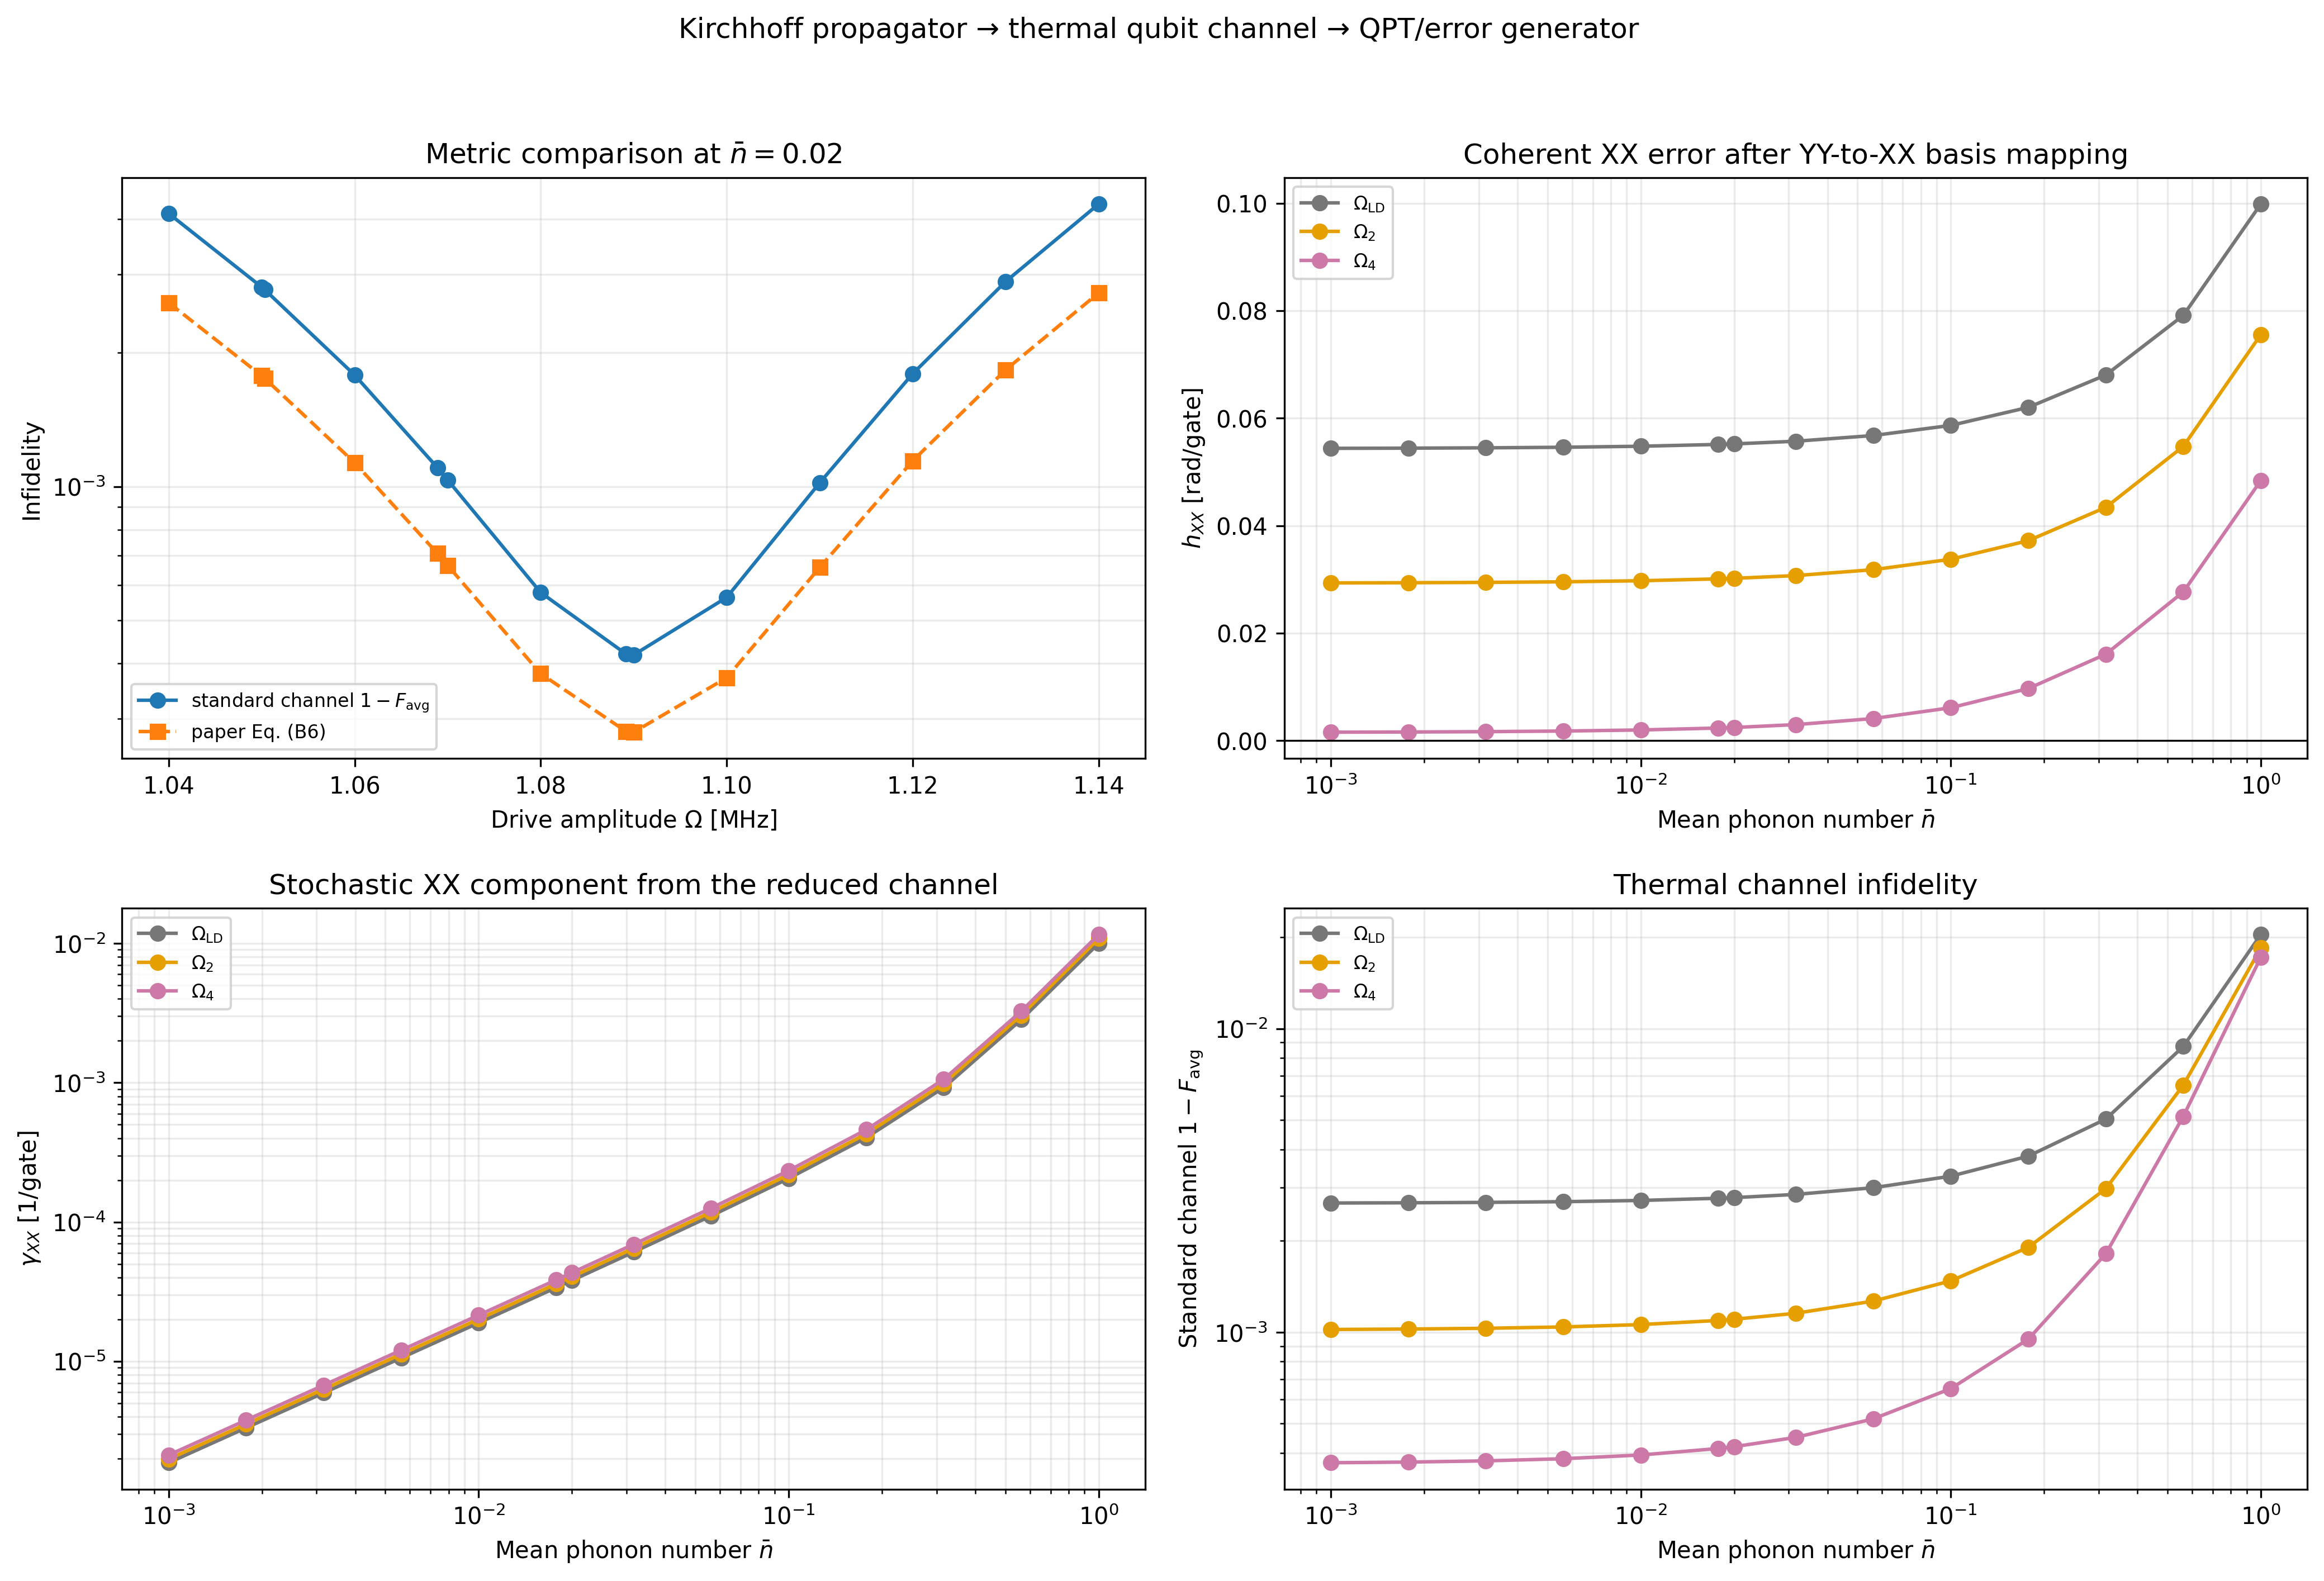

In [48]:
import importlib
from IPython.display import Image

stages = importlib.reload(stages)
if "KIRCHHOFF_PAPER_RESULT" not in globals():
    raise RuntimeError("Run Cell 8.1 first to load the propagator caches.")

# n_barを増やしてもHamiltonian時間発展は不要。熱重みとqubit channelだけ再計算する。
KIRCHHOFF_CHANNEL_NBARS = KIRCHHOFF_PAPER_NBARS
FORCE_KIRCHHOFF_CHANNEL_QPT_RECOMPUTE = False
SHOW_KIRCHHOFF_CHANNEL_QPT_PROGRESS = True

KIRCHHOFF_CHANNEL_RESULT = stages.run_kirchhoff_thermal_qubit_qpt_stage(
    CONFIG,
    KIRCHHOFF_PAPER_RESULT,
    nbar_values=KIRCHHOFF_CHANNEL_NBARS,
    convention=CONFIG.get("ERROR_CHANNEL_CONVENTION", "undo_before_actual"),
    force_recompute=FORCE_KIRCHHOFF_CHANNEL_QPT_RECOMPUTE,
    show_progress=SHOW_KIRCHHOFF_CHANNEL_QPT_PROGRESS,
)
print(KIRCHHOFF_CHANNEL_RESULT["status"])

KIRCHHOFF_CHANNEL_SUMMARY = KIRCHHOFF_CHANNEL_RESULT["summary"]
if not KIRCHHOFF_CHANNEL_SUMMARY.empty:
    reference_nbar = KIRCHHOFF_CHANNEL_SUMMARY.loc[
        (KIRCHHOFF_CHANNEL_SUMMARY["n_bar"] - 0.02).abs().idxmin(), "n_bar"
    ]
    landmark_rows = KIRCHHOFF_CHANNEL_SUMMARY.loc[
        np.isclose(KIRCHHOFF_CHANNEL_SUMMARY["n_bar"], reference_nbar)
        & KIRCHHOFF_CHANNEL_SUMMARY["landmark"].isin(
            ["Omega_LD", "Omega_2", "Omega_4"]
        ),
        ["landmark", "omega_mhz", "average_infidelity",
         "paper_average_infidelity", "h_XX_rad_per_gate",
         "gamma_XX_per_gate", "raw_cp_pass", "raw_tp_pass",
         "chi_cptp_projection_frobenius_shift"],
    ].sort_values("omega_mhz")
    print(f"Landmarks at n_bar={reference_nbar:g}")
    display(landmark_rows)

    best_rows = KIRCHHOFF_CHANNEL_SUMMARY.loc[
        KIRCHHOFF_CHANNEL_SUMMARY.groupby("n_bar")["average_infidelity"].idxmin(),
        ["n_bar", "omega_mhz", "landmark", "average_infidelity",
         "h_XX_rad_per_gate", "gamma_XX_per_gate"],
    ].sort_values("n_bar")
    print("Best cached drive point for each n_bar (standard channel metric)")
    display(best_rows)

if KIRCHHOFF_CHANNEL_RESULT["figure_path"] is not None:
    display(Image(filename=str(KIRCHHOFF_CHANNEL_RESULT["figure_path"])))


### 8.3 Kirchhoffモデルと既存シミュレータのcoherent-limit直接比較

両モデルを同じ`K, L, eta, gate duration, n_bar, phonon cutoff`、同じ理想XXゲートとerror-channel規約にそろえ、heating・dephasing・spin noise・scatteringをすべて含まないcoherent limitで比較します。generatorはχを経由せず、

$$\mathcal S_{\rm error}\longrightarrow R_{\rm error}\longrightarrow\log R_{\rm error}$$

から直接計算します。χは診断用出力だけです。

Kirchhoffの$\Omega$はcarrier drive、既存コードの$A$はfirst-sideband couplingなので、

$$A_{\rm sim}=\frac{\eta\Omega T}{2t_{\rm sim}},\qquad \delta_{\rm sim}=\frac{2\pi(K-L)}{t_{\rm sim}}$$

と変換します。重要な点として、既存コードの`use_full_order=True`はKirchhoffの全carrier-sideband Hamiltonianではなく、first-sideband演算子の$\eta^2$補正です。そのため、`own_lamb_dicke`と`own_eta2_corrected`の両方を比較し、モデルを同一視せず近似差を定量化します。

{'completed_own_propagators': 6, 'expected_own_propagators': 6, 'newly_computed': 0, 'pending_own_propagators': 0, 'completed_comparison_points': 24, 'expected_comparison_points': 24, 'generator_path': 'error superoperator -> PTM -> log(PTM)', 'chi_role': 'diagnostic output only; no chi round-trip', 'drive_mapping': 'A_sim = eta * Omega * T / (2 * t_gate_sim)', 'detuning_mapping': 'delta_sim = 2*pi*(K-L)/t_gate_sim', 'noise_rates': 'all zero (coherent limit)', 'K': 28.0, 'L': 25.0, 'eta': 0.18, 'phonon_dim': 8, 'gate_duration_seconds': 2.8e-05, 'model_variants': {'own_lamb_dicke': False, 'own_eta2_corrected': True}, 'cp_pass': 36, 'tp_pass': 36, 'total_analyzed_channels': 36}


,model,landmark,own_average_infidelity,kirchhoff_average_infidelity,own_h_XX_rad_per_gate,kirchhoff_h_XX_rad_per_gate,own_gamma_XX_per_gate,kirchhoff_gamma_XX_per_gate,error_ptm_relative_difference
0,own_eta2_corrected,Omega_2,0.002115,0.001103,0.047130,0.030201,4.688584e-05,0.000041,0.562169
4,own_eta2_corrected,Omega_4,0.000670,0.000420,0.019055,0.002451,5.049219e-05,0.000043,5.482753
8,own_eta2_corrected,Omega_LD,0.004490,0.002775,0.072378,0.055216,4.375493e-05,0.000038,0.312002
12,own_lamb_dicke,Omega_2,0.000198,0.001103,0.015735,0.030201,1.206176e-08,0.000041,0.481553
16,own_lamb_dicke,Omega_4,0.000152,0.000420,-0.013766,0.002451,1.486471e-08,0.000043,5.360321
20,own_lamb_dicke,Omega_LD,0.001427,0.002775,0.042251,0.055216,9.918980e-09,0.000038,0.236576


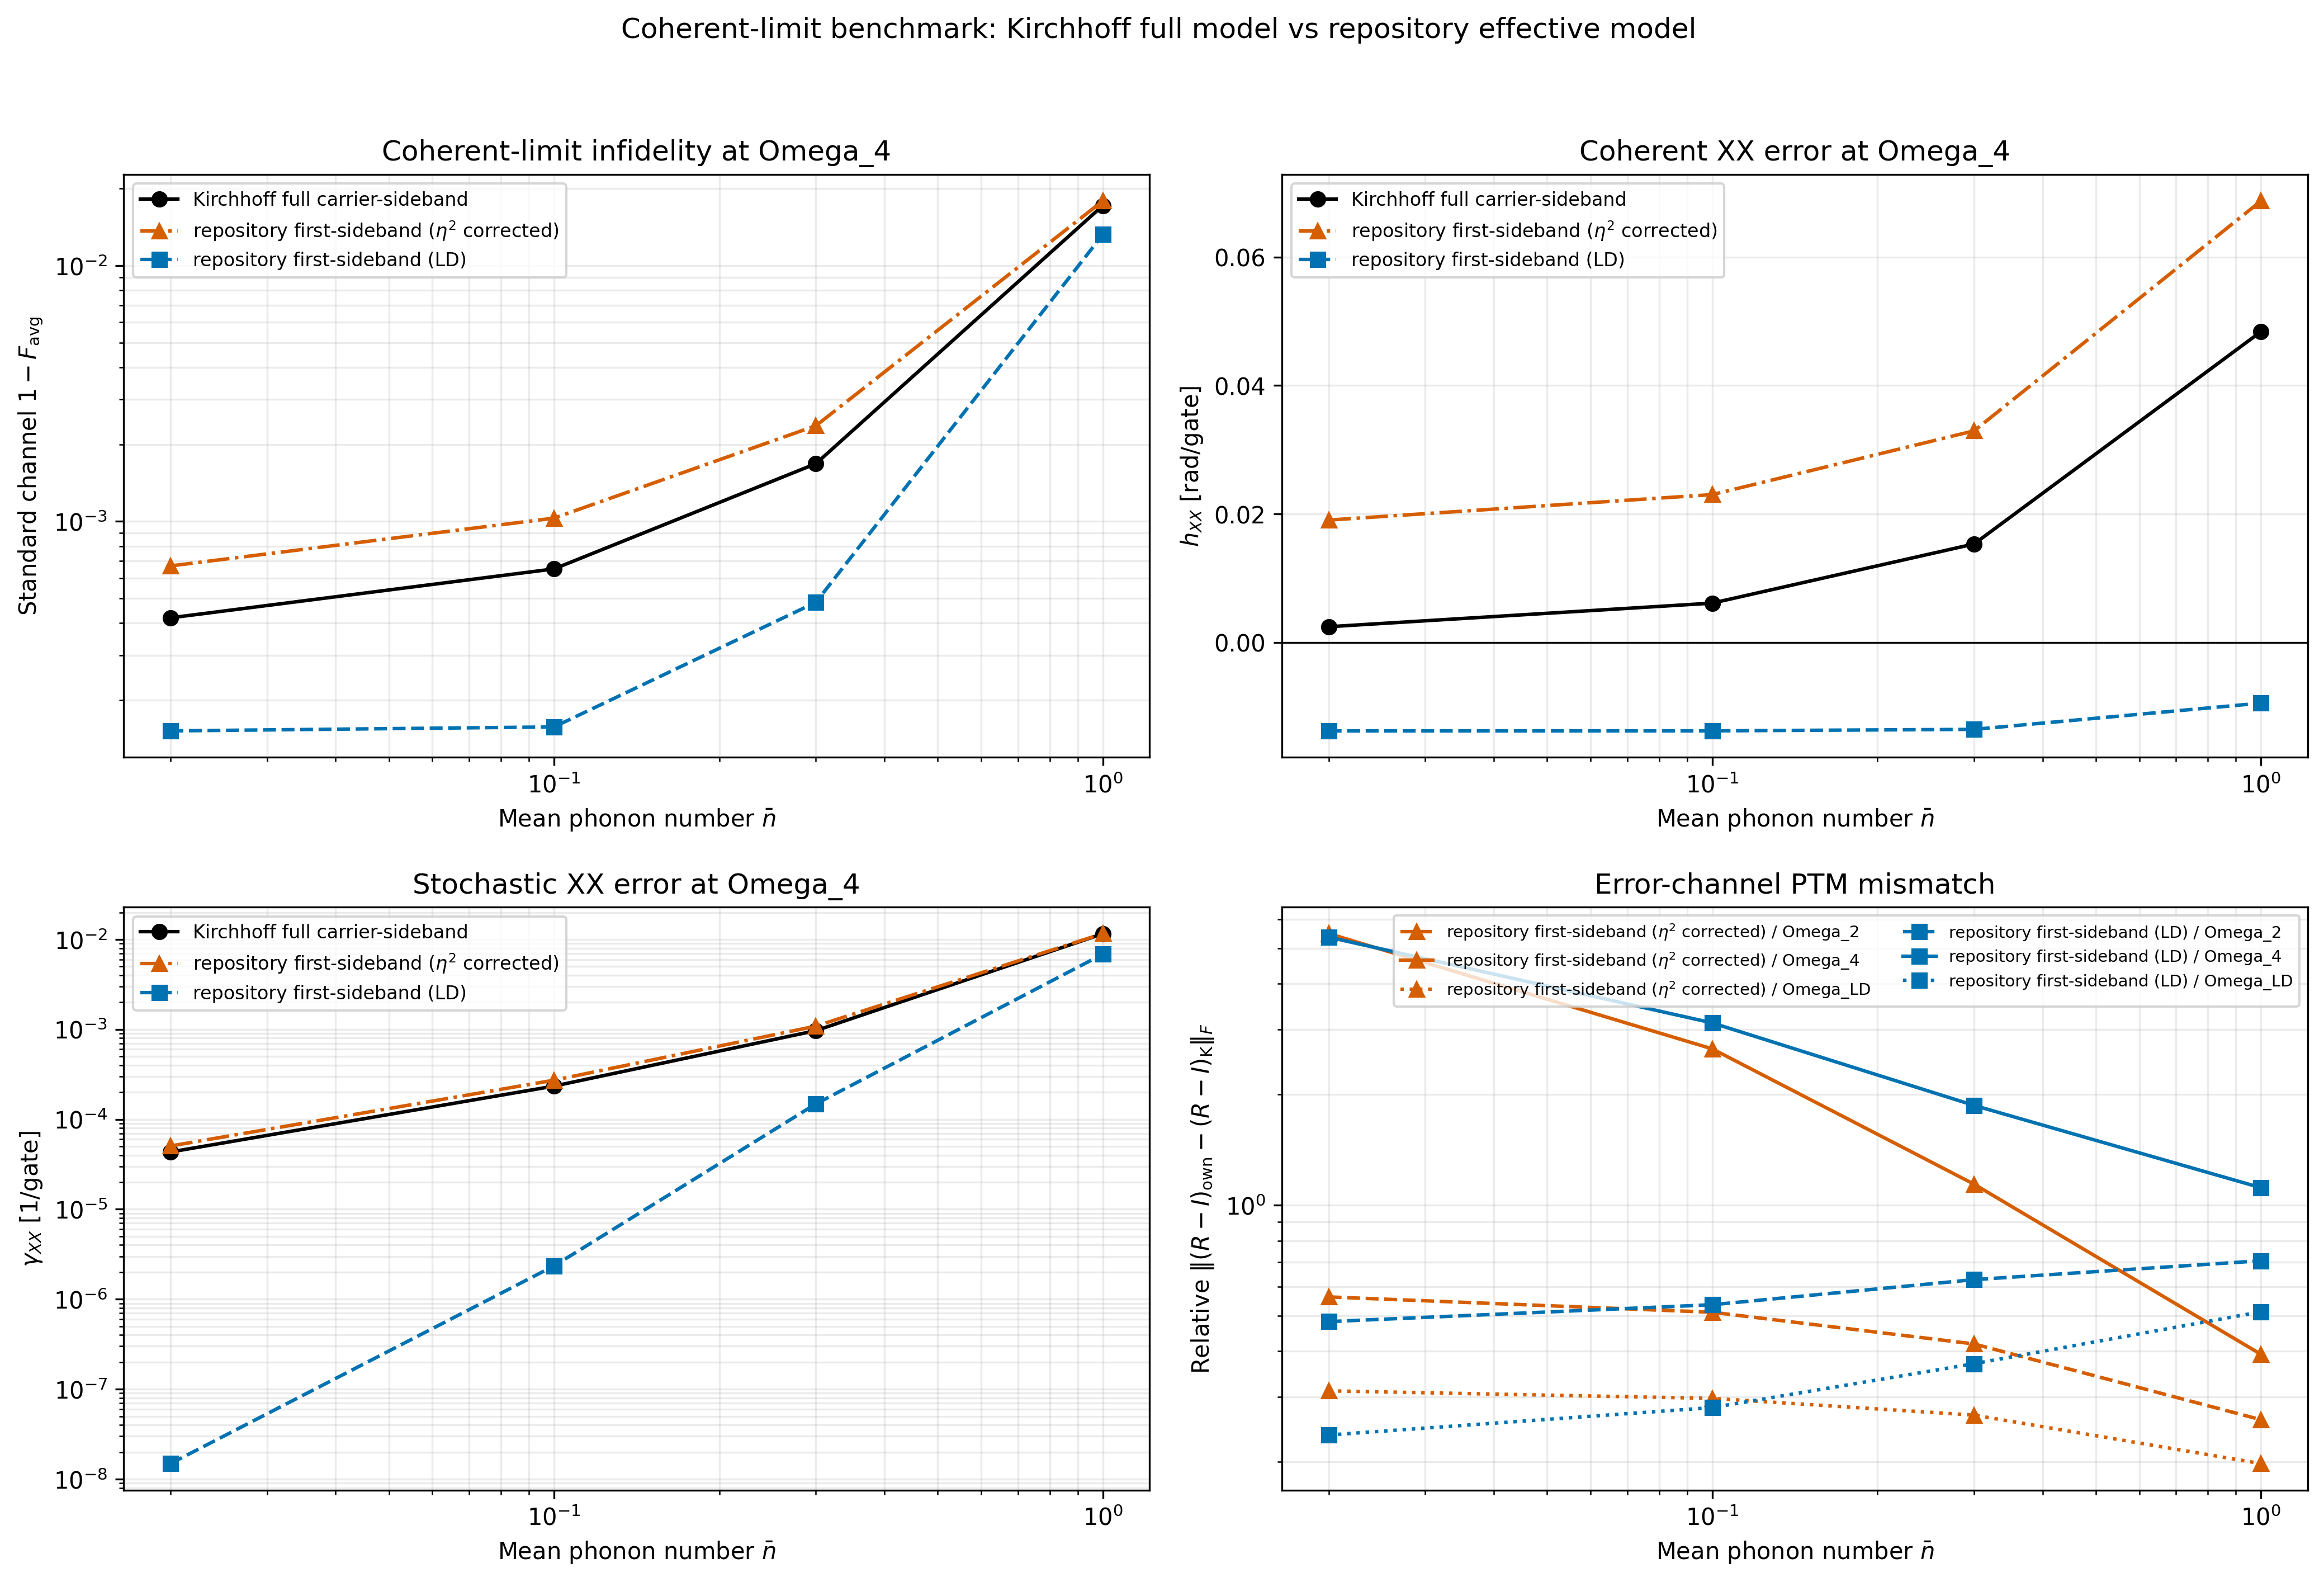

In [59]:
import importlib
from IPython.display import Image

import ms_gate_functions as mg_module
import drive_calibration_qpt_analysis as qpt_analysis_module
import kirchhoff_paper_infidelity as kirchhoff_paper_module
import coherent_limit_comparison as coherent_bridge_module

# Jupyterに残った更新前moduleを依存順に再読込する。
mg_module = importlib.reload(mg_module)
kirchhoff_paper_module = importlib.reload(kirchhoff_paper_module)
qpt_analysis_module = importlib.reload(qpt_analysis_module)
coherent_bridge_module = importlib.reload(coherent_bridge_module)
stages = importlib.reload(stages)
if "KIRCHHOFF_PAPER_RESULT" not in globals():
    raise RuntimeError("Run Cell 8.1 first to load the Kirchhoff propagators.")

KIRCHHOFF_COHERENT_COMPARE_NBARS = [0.02, 0.1, 0.3, 1.0]
KIRCHHOFF_COHERENT_COMPARE_LANDMARKS = ["Omega_LD", "Omega_2", "Omega_4"]
KIRCHHOFF_COHERENT_MODEL_VARIANTS = {
    "own_lamb_dicke": False,
    "own_eta2_corrected": True,
}
KIRCHHOFF_COHERENT_TIME_POINTS = 501
KIRCHHOFF_COHERENT_SOLVER = "vern9"

# Falseでは既存cacheだけを読む。6個のown propagatorを作る場合だけTrue。
RUN_KIRCHHOFF_COHERENT_OWN_PROPAGATION = False
FORCE_KIRCHHOFF_COHERENT_RECOMPUTE = False
SHOW_KIRCHHOFF_COHERENT_PROGRESS = True

KIRCHHOFF_COHERENT_RESULT = stages.run_kirchhoff_coherent_limit_comparison_stage(
    CONFIG,
    KIRCHHOFF_PAPER_RESULT,
    nbar_values=KIRCHHOFF_COHERENT_COMPARE_NBARS,
    landmarks=KIRCHHOFF_COHERENT_COMPARE_LANDMARKS,
    model_variants=KIRCHHOFF_COHERENT_MODEL_VARIANTS,
    time_points=KIRCHHOFF_COHERENT_TIME_POINTS,
    solver_method=KIRCHHOFF_COHERENT_SOLVER,
    run_own_propagation=RUN_KIRCHHOFF_COHERENT_OWN_PROPAGATION,
    force_recompute=FORCE_KIRCHHOFF_COHERENT_RECOMPUTE,
    show_progress=SHOW_KIRCHHOFF_COHERENT_PROGRESS,
)
print(KIRCHHOFF_COHERENT_RESULT["status"])

KIRCHHOFF_COHERENT_COMPARISON = KIRCHHOFF_COHERENT_RESULT["comparison"]
if not KIRCHHOFF_COHERENT_COMPARISON.empty:
    display(KIRCHHOFF_COHERENT_COMPARISON.loc[
        np.isclose(KIRCHHOFF_COHERENT_COMPARISON["n_bar"], 0.02),
        ["model", "landmark", "own_average_infidelity",
         "kirchhoff_average_infidelity", "own_h_XX_rad_per_gate",
         "kirchhoff_h_XX_rad_per_gate", "own_gamma_XX_per_gate",
         "kirchhoff_gamma_XX_per_gate",
         "error_ptm_relative_difference"],
    ].sort_values(["model", "landmark"]))

if KIRCHHOFF_COHERENT_RESULT["figure_path"] is not None:
    display(Image(filename=str(KIRCHHOFF_COHERENT_RESULT["figure_path"])))
if KIRCHHOFF_COHERENT_RESULT["status"]["pending_own_propagators"]:
    print("Set RUN_KIRCHHOFF_COHERENT_OWN_PROPAGATION=True to compute pending own-model propagators.")


### 8.4 モデルごとの $h_{XX}=0$ 校正後に残る構造誤差を比較

Cell 8.3では同じcarrier driveを各Hamiltonianへ入力したため、XX角校正のずれとHamiltonian構造の差が混在していました。このセルでは各`model x n_bar`について$h_{XX}(\Omega)=0$の根を個別に探索します。

既存cache内のdrive点から符号反転区間を探し、safeguarded secant法で必要なpropagatorだけを追加します。校正後は全モデルで$h_{XX}\simeq0$なので、残る

$$\gamma_{XX},\qquad 1-F_{\rm avg},\qquad \|R_{\rm own}-R_{\rm Kirchhoff}\|_F$$

の差をHamiltonian構造そのものによる差として評価できます。generatorはCell 8.3と同じく、error superoperatorからPTMへ直接変換して計算します。

8.4 model-specific hXX=0:   0%|          | 0/12 [00:00<?, ?root/s]

{'converged_roots': 12, 'expected_roots': 12, 'pending_roots': 0, 'newly_computed_propagators': 0, 'pending_propagator_requests': 0, 'hxx_tolerance_rad': 0.0002, 'omega_bounds_mhz': [1.04, 1.18], 'generator_path': 'error superoperator -> PTM -> log(PTM)', 'comparison_meaning': 'hXX individually nulled; residual gamma/infidelity are structural', 'model_variants': {'own_lamb_dicke': False, 'own_eta2_corrected': True}}


,model,n_bar,omega_calibrated_mhz,omega_factor_vs_omega4,h_XX_rad_per_gate,gamma_XX_per_gate,average_infidelity,calibration_converged,calibration_iterations
0,Kirchhoff_full_carrier,0.02,1.090966,1.001629,0.000005,4.356622e-05,4.186241e-04,True,0
1,Kirchhoff_full_carrier,0.10,1.093642,1.004085,0.000009,2.375053e-04,6.348513e-04,True,0
2,Kirchhoff_full_carrier,0.30,1.100434,1.010321,0.000002,1.004649e-03,1.567309e-03,True,0
3,Kirchhoff_full_carrier,1.00,1.124359,1.032286,0.000014,1.241741e-02,1.741230e-02,True,0
4,own_eta2_corrected,0.02,1.102745,1.012443,0.000021,5.301196e-05,4.072195e-04,True,0
5,own_eta2_corrected,0.10,1.105556,1.015023,0.000129,2.888133e-04,6.557880e-04,True,0
6,own_eta2_corrected,0.30,1.112958,1.021819,0.000008,1.184205e-03,1.669390e-03,True,0
7,own_eta2_corrected,1.00,1.138702,1.045455,0.000012,1.329945e-02,1.747350e-02,True,0
8,own_lamb_dicke,0.02,1.079723,0.991306,0.000069,1.349170e-08,3.611518e-08,True,0
9,own_lamb_dicke,0.10,1.079723,0.991306,0.000077,2.217464e-06,5.416732e-06,True,0


After model-specific hXX=0: remaining differences are structural


,model,n_bar,own_omega_calibrated_mhz,kirchhoff_omega_calibrated_mhz,relative_gamma_XX_difference,relative_infidelity_difference,calibrated_ptm_frobenius_difference
0,own_lamb_dicke,0.02,1.079723,1.090966,-0.999690,-0.999914,0.010274
1,own_lamb_dicke,0.10,1.079723,1.093642,-0.990664,-0.991468,0.010091
2,own_lamb_dicke,0.30,1.079931,1.100434,-0.855281,-0.791238,0.011193
3,own_lamb_dicke,1.00,1.082843,1.124359,-0.439801,-0.245257,0.031483
4,own_eta2_corrected,0.02,1.102745,1.090966,0.216813,-0.027243,0.009896
5,own_eta2_corrected,0.10,1.105556,1.093642,0.216029,0.032979,0.009344
6,own_eta2_corrected,0.30,1.112958,1.100434,0.178726,0.065132,0.008339
7,own_eta2_corrected,1.00,1.138702,1.124359,0.071033,0.003515,0.010029


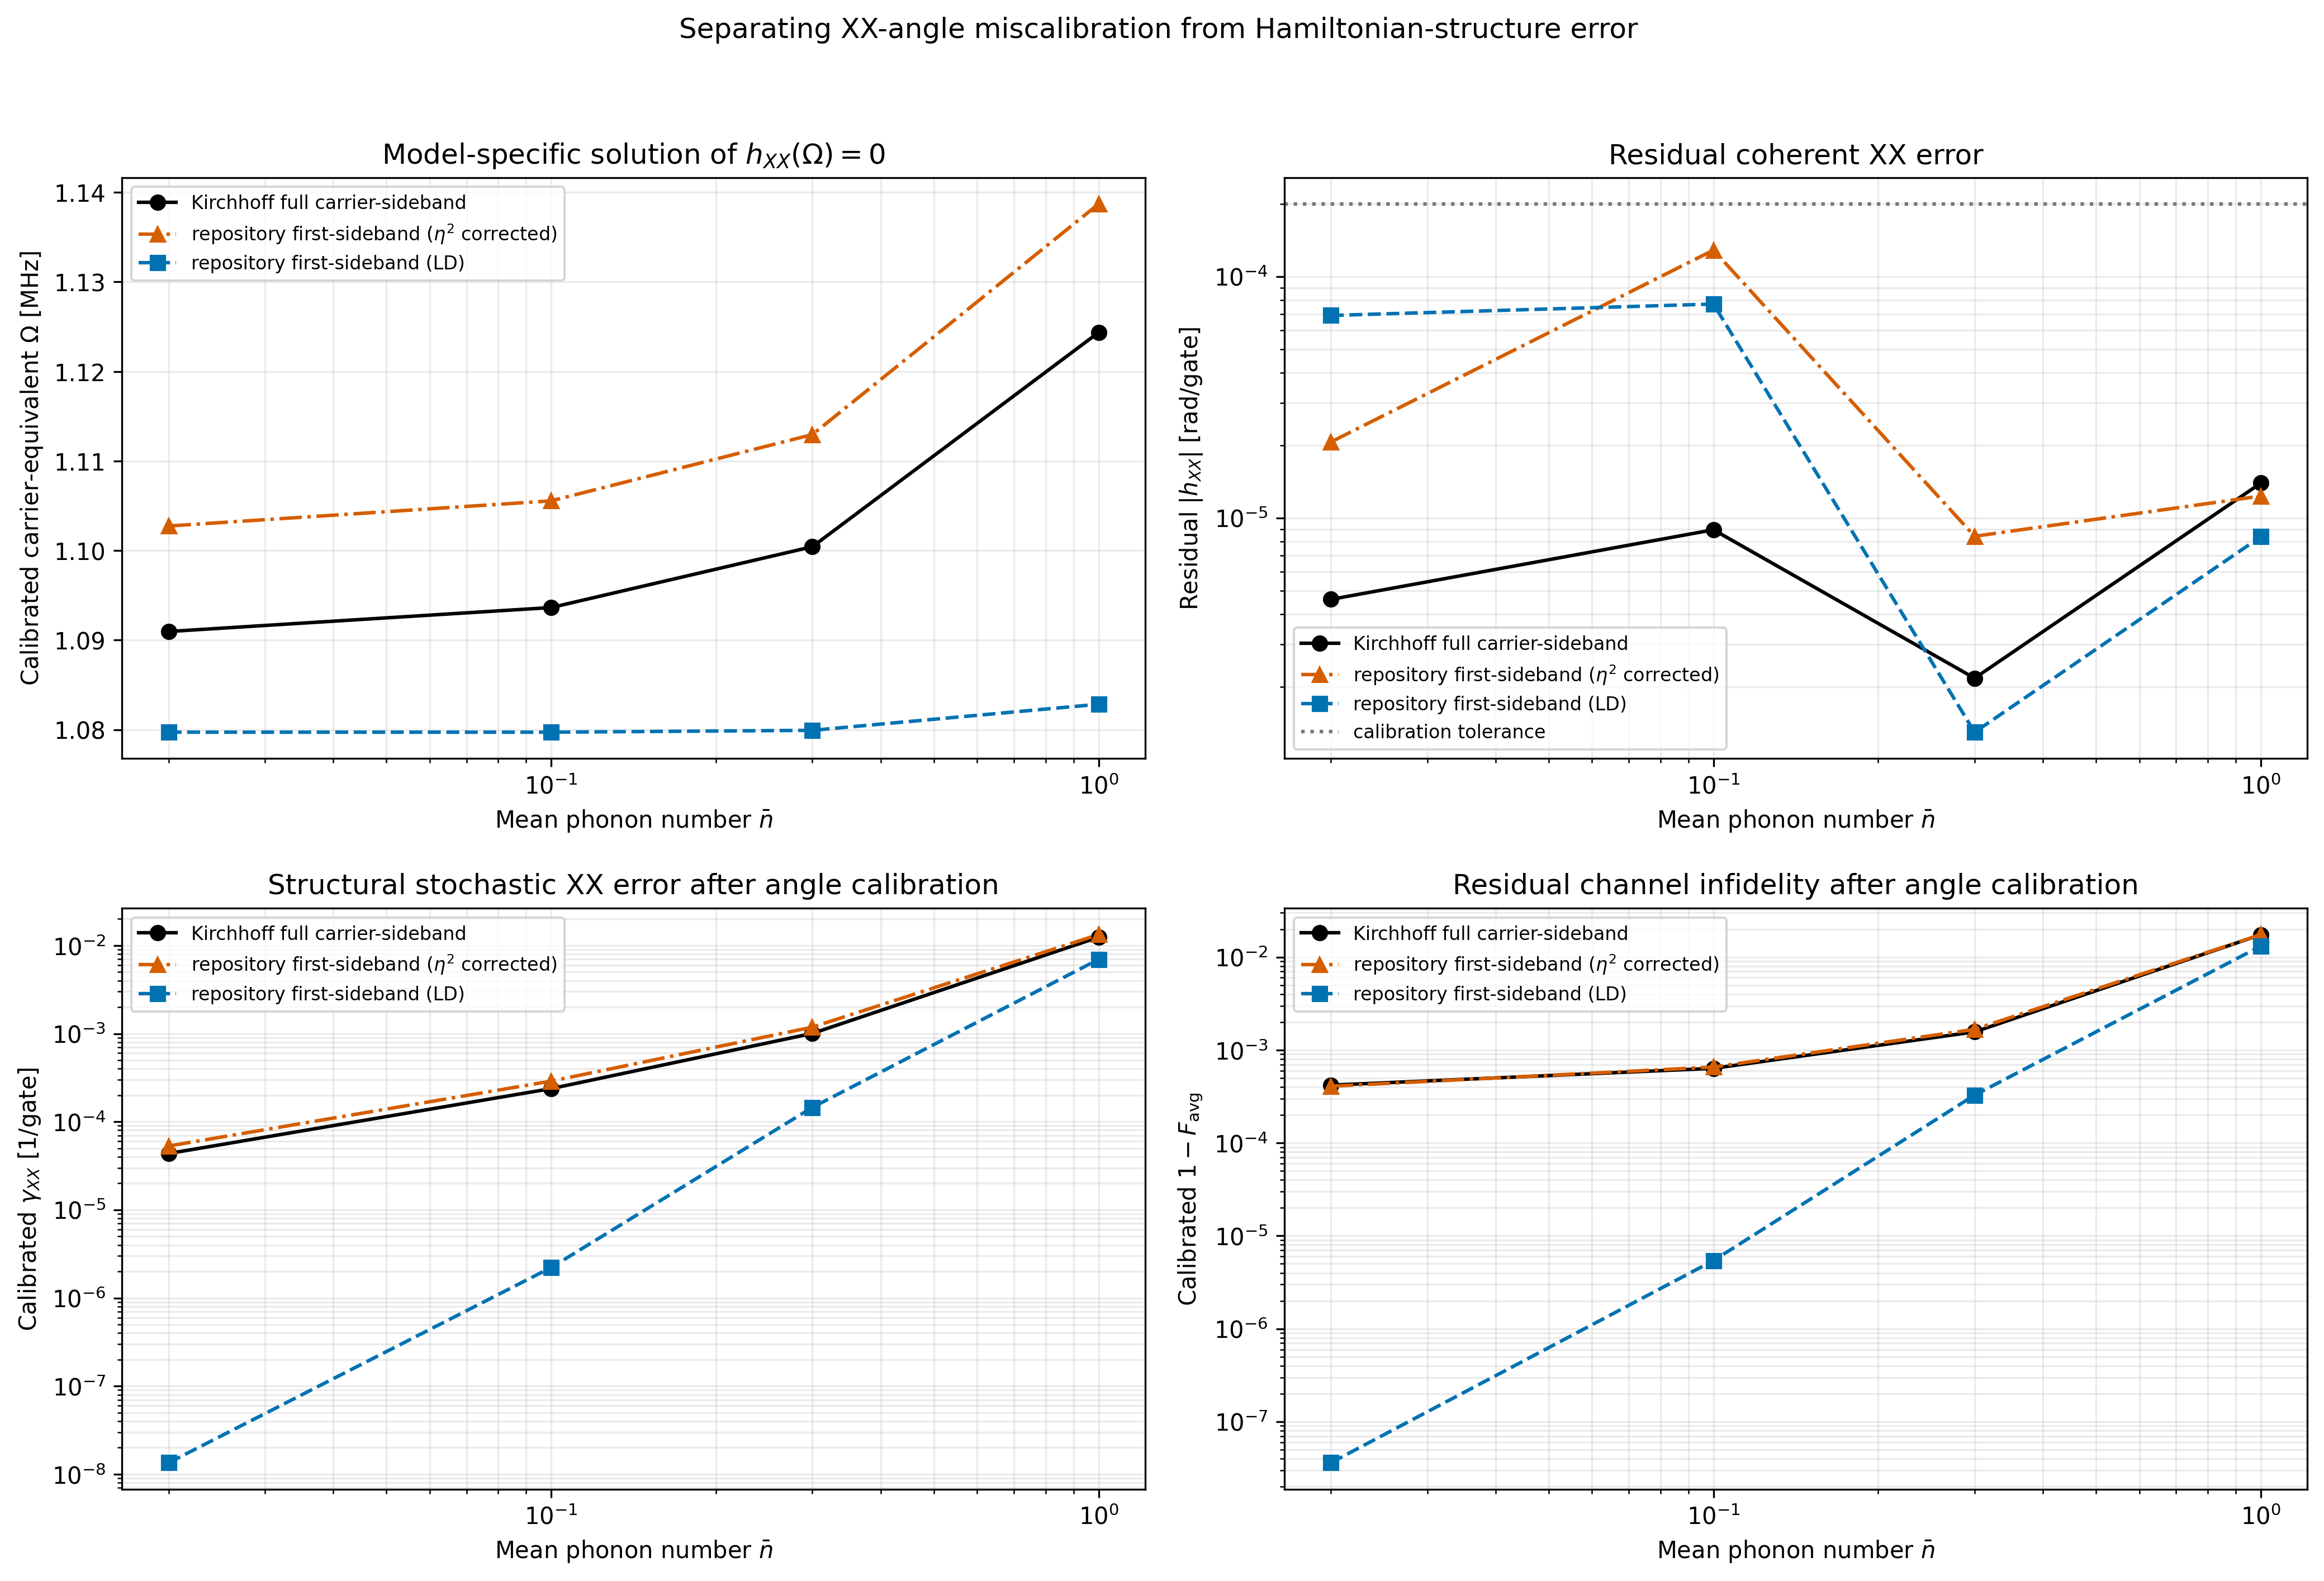

In [61]:
import importlib
from IPython.display import Image

import ms_gate_functions as mg_module
import drive_calibration_qpt_analysis as qpt_analysis_module
import kirchhoff_paper_infidelity as kirchhoff_paper_module
import coherent_limit_comparison as coherent_bridge_module
import model_specific_hxx_calibration as hxx_calibration_module

mg_module = importlib.reload(mg_module)
kirchhoff_paper_module = importlib.reload(kirchhoff_paper_module)
qpt_analysis_module = importlib.reload(qpt_analysis_module)
coherent_bridge_module = importlib.reload(coherent_bridge_module)
hxx_calibration_module = importlib.reload(hxx_calibration_module)
stages = importlib.reload(stages)
if "KIRCHHOFF_PAPER_RESULT" not in globals():
    raise RuntimeError("Run Cell 8.1 first.")
if "KIRCHHOFF_COHERENT_RESULT" not in globals():
    raise RuntimeError("Run Cell 8.3 first.")

MODEL_HXX_ZERO_NBARS = [0.02, 0.1, 0.3, 1.0]
MODEL_HXX_ZERO_OMEGA_BOUNDS_MHZ = (1.04, 1.18)
MODEL_HXX_ZERO_TOLERANCE_RAD = 2.0e-4
MODEL_HXX_ZERO_MAX_ITERATIONS = 3

# 初回の追加propagator計算時だけTrue。現在の既定条件のcacheは作成済み。
RUN_MODEL_HXX_ZERO_PROPAGATION = False
FORCE_MODEL_HXX_ZERO_RECOMPUTE = False
SHOW_MODEL_HXX_ZERO_PROGRESS = True

MODEL_HXX_ZERO_RESULT = stages.run_model_specific_hxx_zero_calibration_stage(
    CONFIG,
    KIRCHHOFF_PAPER_RESULT,
    KIRCHHOFF_COHERENT_RESULT,
    nbar_values=MODEL_HXX_ZERO_NBARS,
    model_variants=KIRCHHOFF_COHERENT_MODEL_VARIANTS,
    omega_bounds_mhz=MODEL_HXX_ZERO_OMEGA_BOUNDS_MHZ,
    hxx_tolerance_rad=MODEL_HXX_ZERO_TOLERANCE_RAD,
    max_root_iterations=MODEL_HXX_ZERO_MAX_ITERATIONS,
    own_time_points=KIRCHHOFF_COHERENT_TIME_POINTS,
    own_solver_method=KIRCHHOFF_COHERENT_SOLVER,
    run_calibration_propagation=RUN_MODEL_HXX_ZERO_PROPAGATION,
    force_recompute=FORCE_MODEL_HXX_ZERO_RECOMPUTE,
    show_progress=SHOW_MODEL_HXX_ZERO_PROGRESS,
)
print(MODEL_HXX_ZERO_RESULT["status"])

MODEL_HXX_ZERO_SUMMARY = MODEL_HXX_ZERO_RESULT["summary"]
if not MODEL_HXX_ZERO_SUMMARY.empty:
    display(MODEL_HXX_ZERO_SUMMARY[[
        "model", "n_bar", "omega_calibrated_mhz",
        "omega_factor_vs_omega4", "h_XX_rad_per_gate",
        "gamma_XX_per_gate", "average_infidelity",
        "calibration_converged", "calibration_iterations",
    ]])

MODEL_HXX_ZERO_STRUCTURAL_COMPARISON = MODEL_HXX_ZERO_RESULT["comparison"]
if not MODEL_HXX_ZERO_STRUCTURAL_COMPARISON.empty:
    print("After model-specific hXX=0: remaining differences are structural")
    display(MODEL_HXX_ZERO_STRUCTURAL_COMPARISON[[
        "model", "n_bar", "own_omega_calibrated_mhz",
        "kirchhoff_omega_calibrated_mhz",
        "relative_gamma_XX_difference",
        "relative_infidelity_difference",
        "calibrated_ptm_frobenius_difference",
    ]])

if MODEL_HXX_ZERO_RESULT["figure_path"] is not None:
    display(Image(filename=str(MODEL_HXX_ZERO_RESULT["figure_path"])))
if MODEL_HXX_ZERO_RESULT["status"]["pending_roots"]:
    print("Set RUN_MODEL_HXX_ZERO_PROPAGATION=True to compute pending calibration points.")


## 9. 独立実行：他の物理制御との比較

固定drive scan、gate time、detuning、$\sin^2$ pulse、Blackman pulseを同じfull-Hamiltonian QPTとCPTP指標で比較します。既定条件は11候補×6温度=66点

In [8]:
CONTROL_QPT_NBARS = [0.01, 1.0, 2.0, 4.0, 10.0, 20.0]
RUN_CONTROL_QPT = True
FORCE_CONTROL_QPT = False
SHOW_CONTROL_PROGRESS = True

DRIVE_AMPLITUDE_FACTORS = [0.95, 1.00, 1.05, 1.10, 1.15, 1.20]
GATE_TIME_FACTORS = [0.97, 1.03]
DETUNING_FACTORS = [0.97, 1.03]
PULSE_SHAPES = ["sin2", "blackman"]

PHYSICAL_CONTROL_RESULT = stages.run_physical_control_stage(
    CONFIG,
    CONTROL_QPT_NBARS,
    run_qpt=RUN_CONTROL_QPT,
    force_recompute=FORCE_CONTROL_QPT,
    show_progress=SHOW_CONTROL_PROGRESS,
    amplitude_factors=DRIVE_AMPLITUDE_FACTORS,
    gate_time_factors=GATE_TIME_FACTORS,
    detuning_factors=DETUNING_FACTORS,
    pulse_shapes=PULSE_SHAPES,
)
print(PHYSICAL_CONTROL_RESULT["status"])
display(PHYSICAL_CONTROL_RESULT["candidates"])
display(PHYSICAL_CONTROL_RESULT["best"])

MS gate simulation progress: 1 n_bar values x 1 laser samples x 16 input states = 16 evolutions (16 evolutions / n_bar)
n_bar = 10.0 Simulation Finished (Dim: 169)
MS gate simulation progress: 3 n_bar values x 1 laser samples x 16 input states = 48 evolutions (16 evolutions / n_bar)
n_bar = 1.0 Simulation Finished (Dim: 25)
n_bar = 2.0 Simulation Finished (Dim: 36)
n_bar = 10.0 Simulation Finished (Dim: 170)
MS gate simulation progress: 6 n_bar values x 1 laser samples x 16 input states = 96 evolutions (16 evolutions / n_bar)
n_bar = 0.01 Simulation Finished (Dim: 20)
n_bar = 1.0 Simulation Finished (Dim: 25)
n_bar = 2.0 Simulation Finished (Dim: 36)
n_bar = 4.0 Simulation Finished (Dim: 68)
n_bar = 10.0 Simulation Finished (Dim: 170)
n_bar = 20.0 Simulation Finished (Dim: 355)
MS gate simulation progress: 6 n_bar values x 1 laser samples x 16 input states = 96 evolutions (16 evolutions / n_bar)
n_bar = 0.01 Simulation Finished (Dim: 20)
n_bar = 1.0 Simulation Finished (Dim: 25)
n_bar 

,name,kind,factor
0,amplitude_0.950,amplitude,0.95
1,amplitude_1.050,amplitude,1.05
2,amplitude_1.100,amplitude,1.10
3,amplitude_1.150,amplitude,1.15
4,amplitude_1.200,amplitude,1.20
5,gate_time_0.970,gate_time,0.97
6,gate_time_1.030,gate_time,1.03
7,detuning_0.970,detuning,0.97
8,detuning_1.030,detuning,1.03
9,pulse_sin2_rms,pulse,1.00


,n_bar,candidate,kind,factor,h_XX_rad_per_gate,gamma_XX_per_gate,average_infidelity,abs_chi_II_XX,chi_XX_XX,generator_imaginary_frobenius_norm,gamma_nnls_residual,cptp_projection_iterations,chi_II_II,chi_IX_IX,chi_XI_XI,coherent_XX_equivalent_weight,control_score
0,0.01,baseline,baseline,1.00,0.013736,0.000164,0.001947,0.013712,0.000353,1.816518e-15,0.004244,1,0.997567,0.000549,0.000549,0.000188,0.001639
1,1.00,detuning_0.970,detuning,0.97,-0.018360,0.000700,0.003528,0.018304,0.001037,2.361773e-15,0.009305,1,0.995590,0.001180,0.001180,0.000337,0.003734
2,2.00,detuning_0.970,detuning,0.97,-0.002515,0.001679,0.004919,0.003019,0.001684,3.042394e-15,0.013722,1,0.993851,0.001726,0.001726,0.000009,0.005145
3,4.00,amplitude_1.050,amplitude,1.05,0.000097,0.005195,0.009372,0.002764,0.005157,4.383841e-16,0.022377,5,0.988286,0.002787,0.002787,0.000008,0.010740
4,10.00,amplitude_1.100,amplitude,1.10,0.018802,0.026986,0.031280,0.018527,0.026367,2.911738e-15,0.047990,5,0.960900,0.005875,0.005875,0.000357,0.038475
5,20.00,amplitude_1.150,amplitude,1.15,0.088929,0.086721,0.084058,0.073455,0.084738,2.093766e-15,0.080444,6,0.894928,0.009676,0.009676,0.006029,0.110119


### 9.1 screening結果の集計とグラフ

保存済みQPTだけを読み、$|h_{XX}|$、$\gamma_{XX}$、physical average infidelity、baseline比を1枚にまとめます。このセルはQPTを再実行しません。

In [ ]:
import importlib
from IPython.display import Image

stages = importlib.reload(stages)
SCREENING_REPORT_NBARS = [0.01, 2.0, 4.0, 10.0, 20.0]

CONTROL_SCREENING_REPORT = stages.run_physical_control_screening_report(
    CONFIG,
    SCREENING_REPORT_NBARS,
)
print(CONTROL_SCREENING_REPORT["status"])
display(CONTROL_SCREENING_REPORT["winners"][[
    "n_bar",
    "best_abs_h_XX_candidate", "h_XX_reduction_factor",
    "best_infidelity_candidate", "infidelity_improvement_factor",
    "best_infidelity_abs_h_XX_ratio",
    "best_infidelity_gamma_XX_ratio",
    "best_control_score_candidate",
]])
display(Image(filename=str(CONTROL_SCREENING_REPORT["figure_path"])))

### 9.2 校正条件をそろえた公平な制御比較

$\bar n=[0.01,2,4,10,20]$の各点で、次の内側校正を行った後に同じfull-Hamiltonian QPTで$|h_{XX}|$、$\gamma_{XX}$、$1-F_{\rm avg}$を比較します。

- rectangular: 完了済みamplitude scanのphysical infidelityを局所2次補間して$A$を選ぶ
- $A,\delta$ joint: amplitude/detuning scanのinfidelity最小値を初期値とし、閉軌道に再スケールする
- gate time: $\delta T=2\pi$とXX角を保った$T/T_0=0.97,1.03$を評価し、infidelityが小さい方を採用する
- $\sin^2$/Blackman: それぞれの$\alpha(T)=0$と幾何学的XX位相$\theta_{XX}=\pi/4$からpulse固有の$\delta,A$を決める

整形pulseの強度が大きい場合もペナルティに入るよう、Rayleigh/Raman scatteringは瞬間$|A(t)|^2$に比例させます。新規QPTは6候補$\times$5温度=30点で、各点を独立にcacheします。まず`RUN_FAIR_CONTROL_QPT=False`のまま実行して校正表を確認し、問題がなければ`True`で未完了点を計算してください。

MS gate simulation progress: 1 n_bar values x 1 laser samples x 16 input states = 16 evolutions (16 evolutions / n_bar)
n_bar = 0.01 Simulation Finished (Dim: 20)
MS gate simulation progress: 1 n_bar values x 1 laser samples x 16 input states = 16 evolutions (16 evolutions / n_bar)
n_bar = 0.01 Simulation Finished (Dim: 20)
MS gate simulation progress: 1 n_bar values x 1 laser samples x 16 input states = 16 evolutions (16 evolutions / n_bar)
n_bar = 0.01 Simulation Finished (Dim: 20)
MS gate simulation progress: 1 n_bar values x 1 laser samples x 16 input states = 16 evolutions (16 evolutions / n_bar)
n_bar = 0.01 Simulation Finished (Dim: 20)
MS gate simulation progress: 1 n_bar values x 1 laser samples x 16 input states = 16 evolutions (16 evolutions / n_bar)
n_bar = 0.01 Simulation Finished (Dim: 20)
MS gate simulation progress: 1 n_bar values x 1 laser samples x 16 input states = 16 evolutions (16 evolutions / n_bar)
n_bar = 0.01 Simulation Finished (Dim: 20)
MS gate simulation pro

,n_bar,condition,amplitude_factor,detuning_factor,gate_time_factor,shape,calibration_method,pulse_relative_closure_residual
0,0.01,drive_detuning_joint,1.000451,0.993389,1.006655,rectangular,quadratic_infidelity_seeds_with_closed_loop_re...,NaN
1,0.01,gate_time_closed_0.970,1.038257,1.030928,0.970000,rectangular,delta_T_2pi_with_angle_rescaling,NaN
2,0.01,gate_time_closed_1.030,0.977776,0.970874,1.030000,rectangular,delta_T_2pi_with_angle_rescaling,NaN
3,0.01,pulse_blackman_calibrated,3.075642,3.000000,1.000000,blackman,ideal_LD_closed_geometric_phase_plus_thermal_hXX,5.562928e-17
4,0.01,pulse_sin2_calibrated,2.210305,2.000000,1.000000,sin2,ideal_LD_closed_geometric_phase_plus_thermal_hXX,1.613019e-17
5,0.01,rectangular_A_infidelity,1.007109,1.000000,1.000000,rectangular,quadratic_physical_infidelity_screening,NaN
6,2.00,drive_detuning_joint,0.999015,0.974013,1.026681,rectangular,quadratic_infidelity_seeds_with_closed_loop_re...,NaN
7,2.00,gate_time_closed_0.970,1.057391,1.030928,0.970000,rectangular,delta_T_2pi_with_angle_rescaling,NaN
8,2.00,gate_time_closed_1.030,0.995795,0.970874,1.030000,rectangular,delta_T_2pi_with_angle_rescaling,NaN
9,2.00,pulse_blackman_calibrated,3.137237,3.000000,1.000000,blackman,ideal_LD_closed_geometric_phase_plus_thermal_hXX,5.562928e-17


,n_bar,condition,h_XX_rad_per_gate,gamma_XX_per_gate,average_infidelity
0,0.01,baseline,0.013736,0.000164,0.001947
1,2.00,baseline,0.043740,0.001485,0.005981
2,4.00,baseline,0.072711,0.004293,0.012281
3,10.00,baseline,0.152443,0.018698,0.040282
4,20.00,baseline,0.265083,0.050513,0.098530
5,0.01,rectangular_A_infidelity,0.002807,0.000169,0.001828
6,0.01,drive_detuning_joint,0.002807,0.000170,0.001832
7,0.01,pulse_sin2_calibrated,-0.002722,0.000031,0.001601
8,0.01,pulse_blackman_calibrated,-0.003789,0.000013,0.002047
9,0.01,gate_time_closed_opt,0.002807,0.000164,0.001811


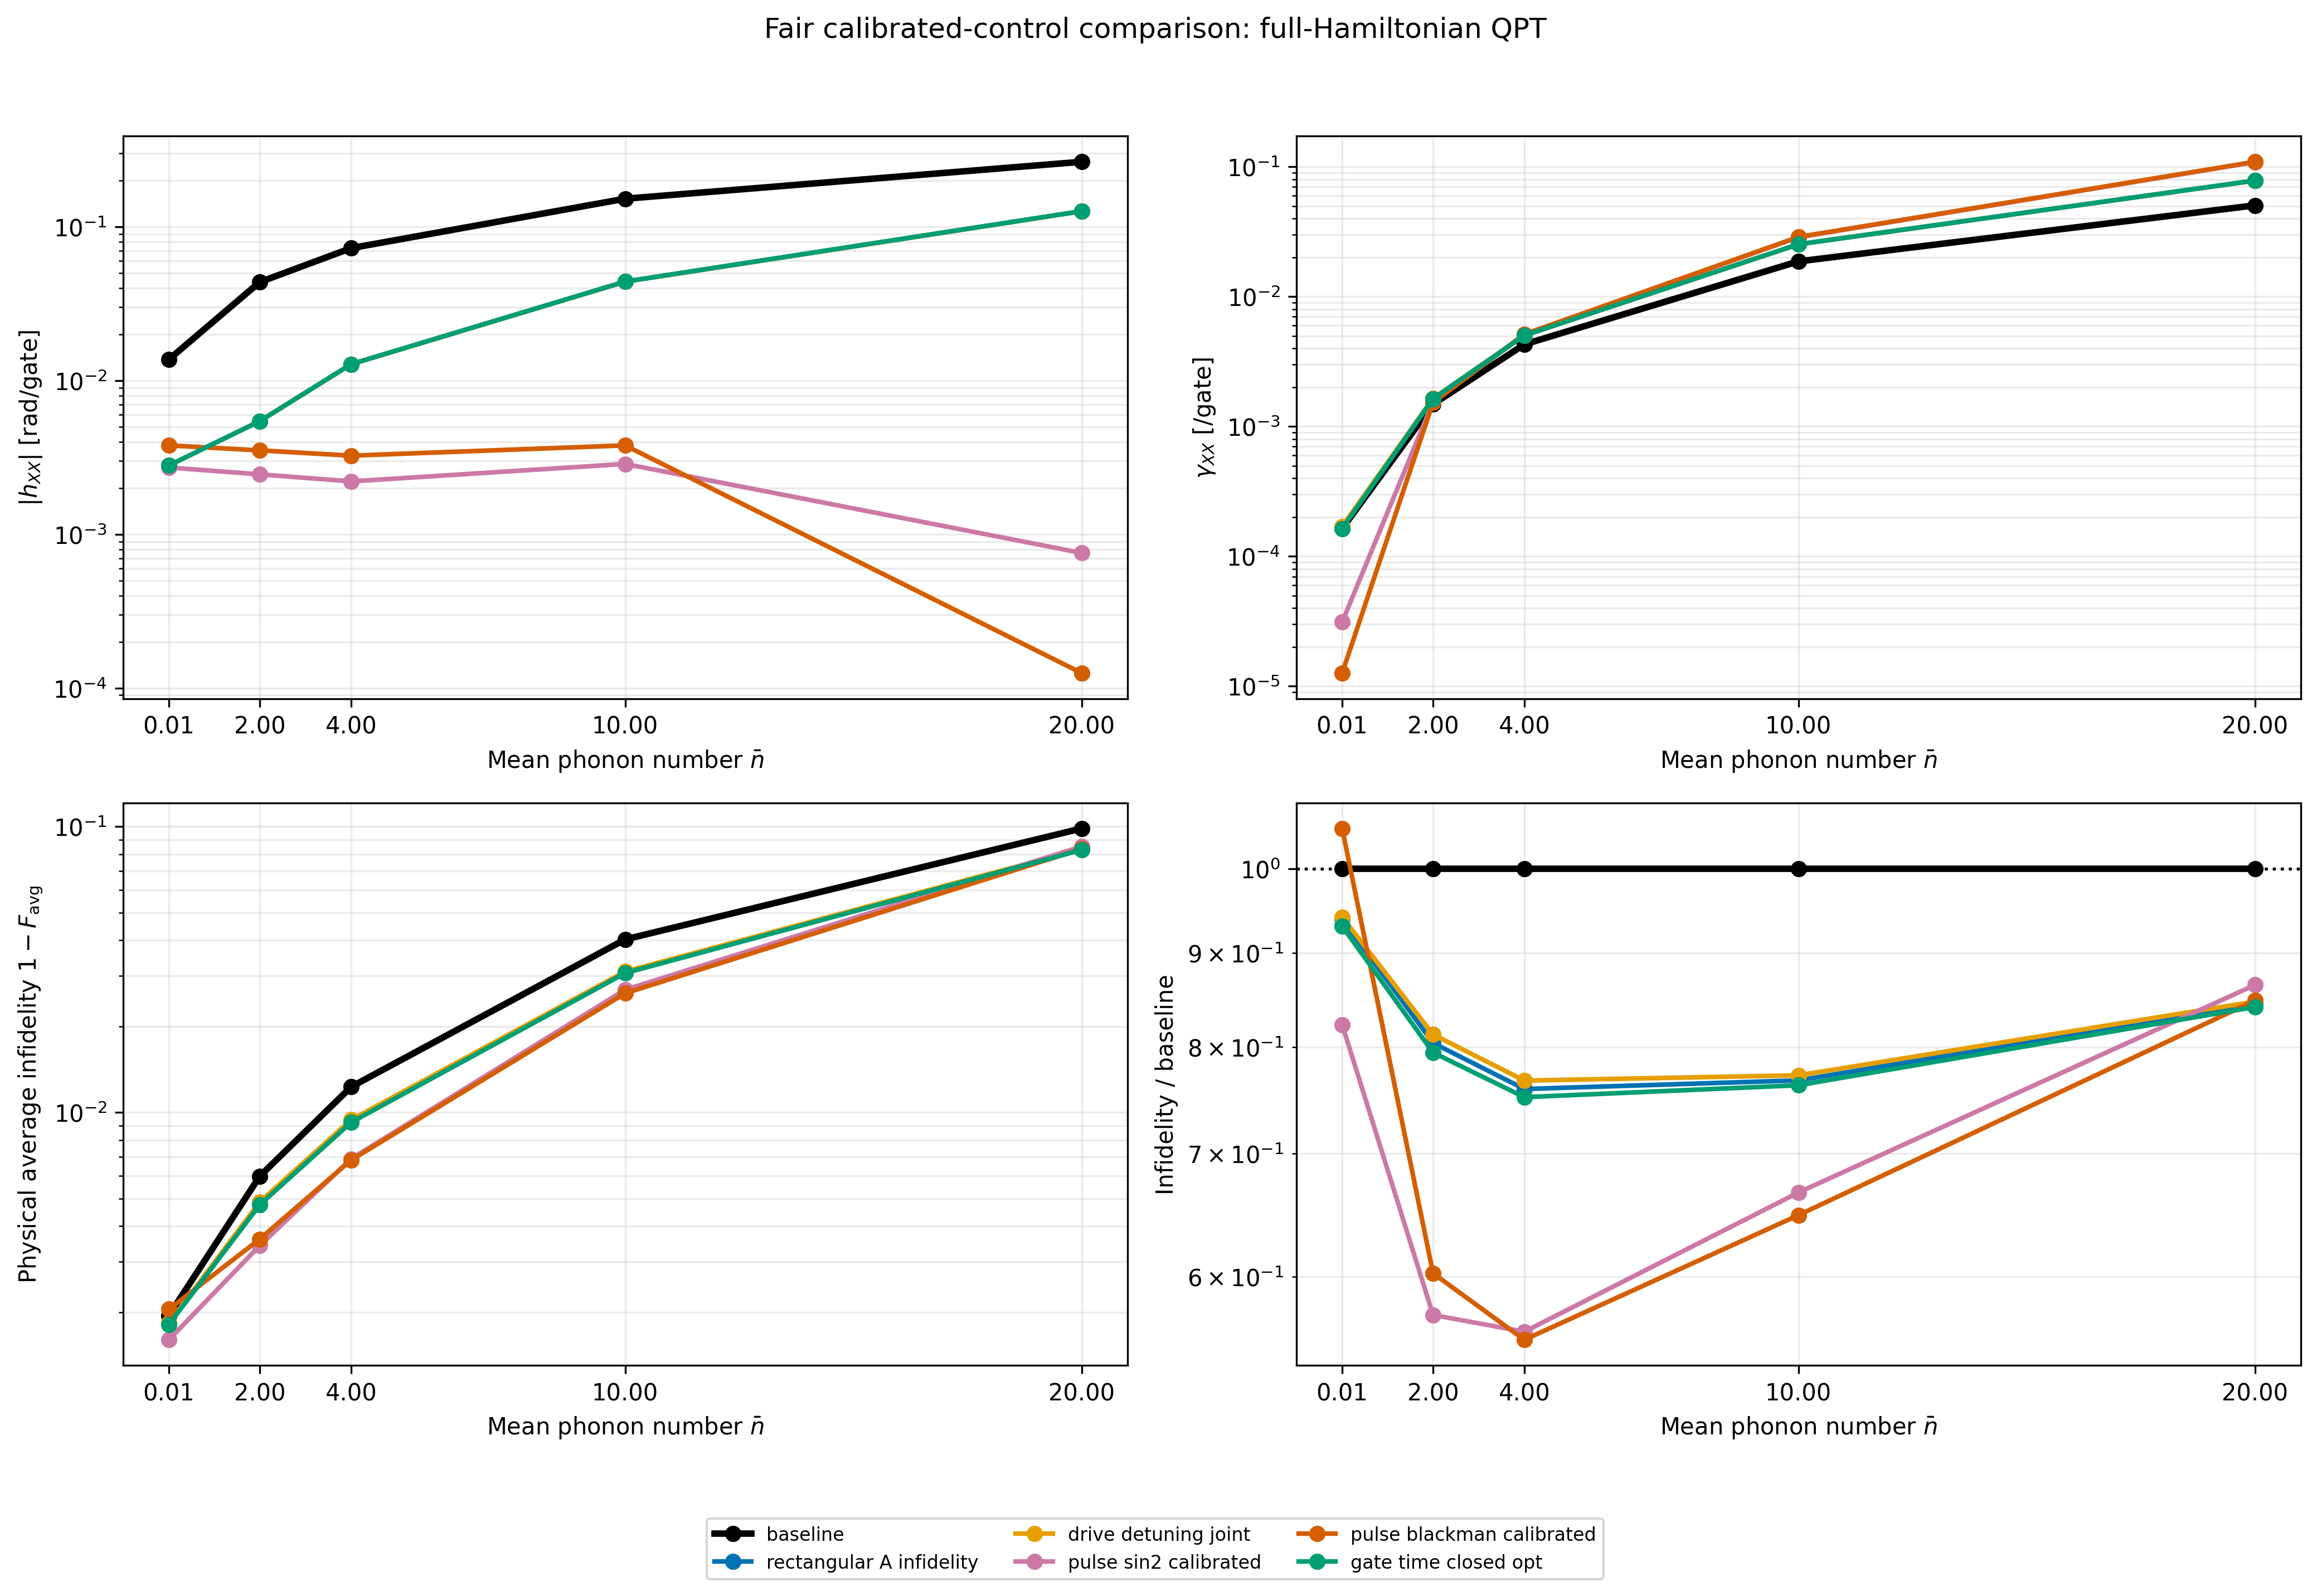

In [10]:
import importlib
from IPython.display import Image

stages = importlib.reload(stages)

FAIR_CONTROL_NBARS = [0.01, 2.0, 4.0, 10.0, 20.0]
RUN_FAIR_CONTROL_QPT = True
FORCE_FAIR_CONTROL_QPT = False
SHOW_FAIR_CONTROL_PROGRESS = True

FAIR_GATE_TIME_FACTORS = [0.97, 1.03]
FAIR_PULSE_CLOSURE_CYCLES = {"sin2": 2.0, "blackman": 3.0}
FAIR_SCATTERING_SCALES_WITH_INTENSITY = True

FAIR_CONTROL_RESULT = stages.run_fair_control_comparison_stage(
    CONFIG,
    FAIR_CONTROL_NBARS,
    run_qpt=RUN_FAIR_CONTROL_QPT,
    force_recompute=FORCE_FAIR_CONTROL_QPT,
    show_progress=SHOW_FAIR_CONTROL_PROGRESS,
    gate_time_factors=FAIR_GATE_TIME_FACTORS,
    pulse_closure_cycles=FAIR_PULSE_CLOSURE_CYCLES,
    scattering_scales_with_intensity=(
        FAIR_SCATTERING_SCALES_WITH_INTENSITY
    ),
)

FAIR_STATUS = FAIR_CONTROL_RESULT["status"]
print({key: value for key, value in FAIR_STATUS.items() if key != "pending"})
print(f"pending QPT points: {len(FAIR_STATUS['pending'])}")
display(FAIR_CONTROL_RESULT["calibration_plan"][[
    "n_bar", "condition", "amplitude_factor", "detuning_factor",
    "gate_time_factor", "shape", "calibration_method",
    "pulse_relative_closure_residual",
]])

if FAIR_STATUS["calibrated_qpt_points_completed"]:
    display(FAIR_CONTROL_RESULT["selected_comparison"][[
        "n_bar", "condition", "h_XX_rad_per_gate",
        "gamma_XX_per_gate", "average_infidelity",
    ]])
    display(Image(filename=str(FAIR_CONTROL_RESULT["figure_path"])))
else:
    print("Calibration plan only. Set RUN_FAIR_CONTROL_QPT=True to run QPT.")

### 9.3 論文用の最終制御検証

9.2で得た候補を初期値とし、次の3点だけを固めます。

1. **公平性**: $\sin^2$/Blackmanの閉軌道$\alpha(T)=0$を保ち、各$\bar n$でpulse固有の$A$を局所再最適化する。既定は全制御共通のpeak-power上限$P_{\max}/P_0=16$。
2. **高温数値検証**: $\bar n=20$の6制御すべてでphonon cutoffを1.15倍、time pointsを2倍にし、単独変更と同時変更を比較する。
3. **クロスオーバー**: $\bar n=12,16$で$A$校正rectangularと高温側の最良shaped pulseを局所再最適化し、infidelityが交差する$\bar n$を推定する。

9.2の中心点は再利用し、新規計算は既定で公平性20点、収束18点、クロスオーバー12点の合計50 QPT点です。各検証は独立フラグと独立cacheを持つため、**一つずつ`True`にして実行**してください。局所最適値が0.98/1.02の境界に来た場合だけ、振幅範囲を広げます。

In [ ]:
import importlib
from IPython.display import Image

stages = importlib.reload(stages)

PAPER_FAIRNESS_NBARS = [0.01, 2.0, 4.0, 10.0, 20.0]
LOCAL_AMPLITUDE_SCALE_FACTORS = [0.98, 1.00, 1.02]

PAPER_RESOURCE_MODE = "peak_power"
COMMON_MAX_PEAK_POWER_FACTOR = 16.0
COMMON_MAX_PULSE_ENERGY_FACTOR = 5.0

HIGH_TEMPERATURE_NBAR = 20.0
PHONON_CUTOFF_FACTOR = 1.15
TIME_POINTS_FACTOR = 2.0

CROSSOVER_NBARS = [12.0, 16.0]
CROSSOVER_SHAPE = "auto"

# 重いため、fairness -> convergence -> crossoverの順に
# 一つずつTrueにする。完了点はcacheから再利用される。
RUN_PAPER_FAIRNESS_QPT = False
RUN_HIGH_TEMPERATURE_CONVERGENCE_QPT = False
RUN_CROSSOVER_QPT = False
FORCE_PUBLICATION_CONTROL_RECOMPUTE = False
SHOW_PUBLICATION_CONTROL_PROGRESS = True

PUBLICATION_CONTROL_RESULT = stages.run_publication_control_validation_stage(
    CONFIG,
    fairness_nbars=PAPER_FAIRNESS_NBARS,
    amplitude_scale_factors=LOCAL_AMPLITUDE_SCALE_FACTORS,
    resource_mode=PAPER_RESOURCE_MODE,
    max_peak_power_factor=COMMON_MAX_PEAK_POWER_FACTOR,
    max_pulse_energy_factor=COMMON_MAX_PULSE_ENERGY_FACTOR,
    convergence_nbar=HIGH_TEMPERATURE_NBAR,
    phonon_cutoff_factor=PHONON_CUTOFF_FACTOR,
    time_points_factor=TIME_POINTS_FACTOR,
    crossover_nbars=CROSSOVER_NBARS,
    crossover_shape=CROSSOVER_SHAPE,
    run_fairness_qpt=RUN_PAPER_FAIRNESS_QPT,
    run_convergence_qpt=RUN_HIGH_TEMPERATURE_CONVERGENCE_QPT,
    run_crossover_qpt=RUN_CROSSOVER_QPT,
    force_recompute=FORCE_PUBLICATION_CONTROL_RECOMPUTE,
    show_progress=SHOW_PUBLICATION_CONTROL_PROGRESS,
)

display(pd.DataFrame(PUBLICATION_CONTROL_RESULT["status"]).T)

FAIRNESS_SELECTED = PUBLICATION_CONTROL_RESULT["fairness_selected"]
if not FAIRNESS_SELECTED.empty:
    display(FAIRNESS_SELECTED[[
        "n_bar", "condition", "amplitude_peak", "peak_power_factor",
        "pulse_energy_factor", "ideal_closure_residual",
        "average_infidelity", "h_XX_rad_per_gate", "gamma_XX_per_gate",
        "local_optimum_at_boundary",
    ]].sort_values(["n_bar", "condition"]))

CONVERGENCE_COMPARISON = PUBLICATION_CONTROL_RESULT["convergence_comparison"]
if (
    not CONVERGENCE_COMPARISON.empty
    and "relative_infidelity_to_high_resolution" in CONVERGENCE_COMPARISON
):
    display(CONVERGENCE_COMPARISON.sort_values([
        "condition", "convergence_level_order"
    ])[[
        "condition", "convergence_level", "phonon_dim_actual", "time_points",
        "raw_cp_pass", "raw_min_choi_eigenvalue",
        "relative_infidelity_to_high_resolution",
        "relative_abs_h_to_high_resolution",
        "relative_gamma_to_high_resolution",
    ]])

CROSSOVER_CURVE = PUBLICATION_CONTROL_RESULT["crossover_curve"]
if not CROSSOVER_CURVE.empty:
    display(CROSSOVER_CURVE)
    print(
        "estimated crossover n_bar =",
        PUBLICATION_CONTROL_RESULT["status"]["crossover"]["estimated_n_bar"],
    )

if PUBLICATION_CONTROL_RESULT["figure_path"] is not None:
    display(Image(filename=str(PUBLICATION_CONTROL_RESULT["figure_path"])))

## 10. 独立実行：パラメータ頑健性

$\eta$、$A/\delta$、gate time、motional dephasing rateを個別に変更し、$h_{XX}$、$\gamma_{XX}$、average infidelityを再評価します。既定条件は9条件×5温度=45点です。条件全体と各条件内のQPT evolutionを2段のprogress barで表示します。

In [ ]:
ROBUSTNESS_QPT_NBARS = [0.01, 1.0, 2.0, 4.0, 6.0, 8.0, 10.0, 12.0, 16.0, 20.0]
RUN_ROBUSTNESS_QPT = True
FORCE_ROBUSTNESS_QPT = True
SHOW_ROBUSTNESS_PROGRESS = True

ETA_FACTORS = [0.8, 1.2]
A_OVER_DELTA_FACTORS = [0.9, 1.1]
ROBUSTNESS_GATE_TIME_FACTORS = [0.95, 1.05]
MOTIONAL_DEPHASING_FACTORS = [0.0, 0.5, 2.0]

ROBUSTNESS_RESULT = stages.run_parameter_robustness_stage(
    CONFIG,
    ROBUSTNESS_QPT_NBARS,
    run_qpt=RUN_ROBUSTNESS_QPT,
    force_recompute=FORCE_ROBUSTNESS_QPT,
    show_progress=SHOW_ROBUSTNESS_PROGRESS,
    eta_factors=ETA_FACTORS,
    a_over_delta_factors=A_OVER_DELTA_FACTORS,
    gate_time_factors=ROBUSTNESS_GATE_TIME_FACTORS,
    motional_dephasing_factors=MOTIONAL_DEPHASING_FACTORS,
)
print(ROBUSTNESS_RESULT["status"])
display(ROBUSTNESS_RESULT["conditions"])
display(ROBUSTNESS_RESULT["summary"])

## 11. 主要結果

詳細なCSV・PNG・PDFは`CONFIG["OUTPUT_DIR"]`以下へ保存されます。

In [ ]:
RESULT_TABLES = [
    "fit_summary_df",
    "advanced_publication_summary_df",
    "final_drive_calibration_df",
]
for table_name in RESULT_TABLES:
    table = RESULTS.get(table_name)
    if isinstance(table, pd.DataFrame) and not table.empty:
        print(table_name)
        display(table)

In [8]:
import os

CPU_COUNT = os.cpu_count() or 4
WORKERS = max(1, min(8, CPU_COUNT - 2))

CONFIG["PARALLEL_WORKERS"] = WORKERS
CONFIG["FAST_PROCESS_WORKERS"] = WORKERS

print(f"Detected logical CPUs: {CPU_COUNT}")
print(f"QPT workers: {WORKERS}")

Detected logical CPUs: 48
QPT workers: 8
